<a href="https://colab.research.google.com/github/rubiakuhne123/TCC_MBAUSPEsalq/blob/main/TCC_MBAUSPEsalq_RubiaDiazTaveirosKuhne.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***INSTALAÇÃO E IMPORTAÇÃO PACOTES PYTHON***

> Add blockquote



In [ ]:

import pandas as pd
import numpy as np
import glob
import os
import unicodedata
import re
import io

from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# ***TRATAMENTO DOS DADOS DO SINAN***

In [ ]:
caminho_pasta = "/content/drive/MyDrive/Leptospirose/SINAN/*.csv"

arquivos_casos = glob.glob(caminho_pasta)

print(f"Total de arquivos encontrados: {len(arquivos_casos)}")
print("Arquivos identificados:")
for a in arquivos_casos:
    print(a)

Total de arquivos encontrados: 18
Arquivos identificados:
/content/drive/MyDrive/Leptospirose/SINAN/SINAN_2010.csv
/content/drive/MyDrive/Leptospirose/SINAN/SINAN_2011.csv
/content/drive/MyDrive/Leptospirose/SINAN/SINAN_2012.csv
/content/drive/MyDrive/Leptospirose/SINAN/SINAN_2013.csv
/content/drive/MyDrive/Leptospirose/SINAN/SINAN_2014.csv
/content/drive/MyDrive/Leptospirose/SINAN/SINAN_2015.csv
/content/drive/MyDrive/Leptospirose/SINAN/SINAN_2016.csv
/content/drive/MyDrive/Leptospirose/SINAN/SINAN_2017.csv
/content/drive/MyDrive/Leptospirose/SINAN/SINAN_2018.csv
/content/drive/MyDrive/Leptospirose/SINAN/SINAN_2019.csv
/content/drive/MyDrive/Leptospirose/SINAN/SINAN_2020.csv
/content/drive/MyDrive/Leptospirose/SINAN/SINAN_2021.csv
/content/drive/MyDrive/Leptospirose/SINAN/SINAN_2022.csv
/content/drive/MyDrive/Leptospirose/SINAN/SINAN_2023.csv
/content/drive/MyDrive/Leptospirose/SINAN/SINAN_2008.csv
/content/drive/MyDrive/Leptospirose/SINAN/SINAN_2009.csv
/content/drive/MyDrive/Leptosp

In [ ]:
lista_casos = []
for arquivo in arquivos_casos:
    ano = os.path.basename(arquivo).split('_')[1].split('.')[0]
    df = pd.read_csv(arquivo, encoding='latin1', sep=',')
    df = df.melt(id_vars=['MES'], var_name='ESTADO', value_name='CASOS')
    df['ANO'] = int(ano)
    lista_casos.append(df)

casos = pd.concat(lista_casos, ignore_index=True)

# ***TRATAMENTO DOS DADOS DO INMET***

## *2008*

In [ ]:
PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET/2008")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
N_LINHAS_PULAR = 8
ENC = "latin1"



arquivos_csv = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f" Total de arquivos encontrados: {len(arquivos_csv)}\n")



ok = 0
erros = []

for arquivo in arquivos_csv:
    try:

        with open(arquivo, 'r', encoding=ENC) as f:
            linhas = f.readlines()

        linhas_dados = linhas[N_LINHAS_PULAR:]

        linhas_processadas = [linhas_dados[0]]

        for linha in linhas_dados[1:]:

            linha_corrigida = linha.replace(',', '.')
            linhas_processadas.append(linha_corrigida)

        conteudo = ''.join(linhas_processadas)
        df = pd.read_csv(
            io.StringIO(conteudo),
            sep=SEP,
            engine="python",
            on_bad_lines="skip"
        )

        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)

        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(
            arquivo_destino,
            sep=SEP,
            index=False,
            encoding=ENC
        )

        ok += 1
        if ok <= 5:
            print(f"{arquivo.name} → {df.shape[0]} linhas, {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"{arquivo.name}: {e}")



print(f"\n{'='*80}")
print(f"ETAPA 1 CONCLUÍDA")
print(f"{'='*80}")
print(f"Processados: {ok}/{len(arquivos_csv)}")
print(f"Erros: {len(erros)}")

if erros:
    print(f"\n  Primeiros erros:")
    for nome, erro in erros[:10]:
        print(f"   • {nome}: {erro[:60]}")

 Total de arquivos encontrados: 25

INMET_CO_DF_A001_BRASILIA_01-01-2008_A_31-12-2008.CSV → 8784 linhas, 20 colunas
INMET_CO_GO_A002_GOIANIA_01-01-2008_A_31-12-2008.CSV → 8784 linhas, 20 colunas
INMET_CO_MS_A702_CAMPO GRANDE_01-01-2008_A_31-12-2008.CSV → 8784 linhas, 20 colunas
INMET_CO_MT_A901_CUIABA_01-01-2008_A_31-12-2008.CSV → 8784 linhas, 20 colunas
INMET_NE_AL_A303_MACEIO_01-01-2008_A_31-12-2008.CSV → 8784 linhas, 20 colunas

ETAPA 1 CONCLUÍDA
Processados: 25/25
Erros: 0


In [ ]:

PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO/2008")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
ENC = "latin1"
SENTINEL = -9999



MAPEAMENTO_EXATO = {
    "DATA (YYYY-MM-DD)": "DATA",
    "HORA (UTC)": "HORA",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "PRECIPITACAO",
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "PRESSAO",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)": "PRESSAO_MAX",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)": "PRESSAO_MIN",
    "RADIACAO GLOBAL (KJ/m²)": "RADIACAO",
    "RADIACAO GLOBAL (Kj/m²)": "RADIACAO",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "TEMPERATURA",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)": "TEMPERATURA_ORVALHO",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)": "TEMP_MAX",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)": "TEMP_MIN",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MAX",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MIN",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)": "UMIDADE_MAX",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)": "UMIDADE_MIN",
    "UMIDADE RELATIVA DO AR, HORARIA (%)": "UMIDADE",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))": "VENTO_DIR",
    "VENTO, RAJADA MAXIMA (m/s)": "VENTO_RAJ",
    "VENTO, VELOCIDADE HORARIA (m/s)": "VENTO_VEL",
    "Data": "DATA",
    "Hora UTC": "HORA",
}


arquivos = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f"Arquivos para processar: {len(arquivos)}\n")

ok = 0
erros = []

for arquivo in arquivos:
    try:

        df = pd.read_csv(arquivo, sep=SEP, encoding=ENC)

        print(f"\n📄 {arquivo.name}")
        print(f"   Colunas ANTES: {df.shape[1]}")


        df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", regex=True, na=False)]
        df = df.dropna(axis=1, how='all')

        print(f"   Colunas depois de limpar: {df.shape[1]}")


        df = df.rename(columns=MAPEAMENTO_EXATO)

        print(f"   Colunas DEPOIS: {df.shape[1]}")
        print(f"   Nomes das colunas: {df.columns.tolist()[:5]}...")


        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) > 0:
            df[num_cols] = df[num_cols].replace(SENTINEL, pd.NA)


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(arquivo_destino, sep=SEP, index=False, encoding=ENC)

        ok += 1
        print(f"   Salvo: {df.shape[0]} linhas × {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"   ERRO: {e}")


print(f"\n{'='*80}")
print(f"PROCESSAMENTO CONCLUÍDO")
print(f"{'='*80}")
print(f"  Processados: {ok}/{len(arquivos)}")
print(f" Erros: {len(erros)}")

if erros:
    print(f"\n Arquivos com erro:")
    for nome, msg in erros:
        print(f"   • {nome}: {msg[:80]}")


Arquivos para processar: 25


📄 INMET_CO_DF_A001_BRASILIA_01-01-2008_A_31-12-2008.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8784 linhas × 19 colunas

📄 INMET_CO_GO_A002_GOIANIA_01-01-2008_A_31-12-2008.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8784 linhas × 19 colunas

📄 INMET_CO_MS_A702_CAMPO GRANDE_01-01-2008_A_31-12-2008.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8784 linhas × 19 colunas

📄 INMET_CO_MT_A901_CUIABA_01-01-2008_A_31-12-2008.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
 

## *2009*

In [ ]:
PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET/2009")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
N_LINHAS_PULAR = 8
ENC = "latin1"


arquivos_csv = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f" Total de arquivos encontrados: {len(arquivos_csv)}\n")



ok = 0
erros = []

for arquivo in arquivos_csv:
    try:

        with open(arquivo, 'r', encoding=ENC) as f:
            linhas = f.readlines()

        linhas_dados = linhas[N_LINHAS_PULAR:]

        linhas_processadas = [linhas_dados[0]]

        for linha in linhas_dados[1:]:

            linha_corrigida = linha.replace(',', '.')
            linhas_processadas.append(linha_corrigida)

        conteudo = ''.join(linhas_processadas)
        df = pd.read_csv(
            io.StringIO(conteudo),
            sep=SEP,
            engine="python",
            on_bad_lines="skip"
        )

        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)

        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(
            arquivo_destino,
            sep=SEP,
            index=False,
            encoding=ENC
        )

        ok += 1
        if ok <= 5:
            print(f"{arquivo.name} → {df.shape[0]} linhas, {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"{arquivo.name}: {e}")


print(f"\n{'='*80}")
print(f"ETAPA 1 CONCLUÍDA")
print(f"{'='*80}")
print(f"Processados: {ok}/{len(arquivos_csv)}")
print(f"Erros: {len(erros)}")

if erros:
    print(f"\n  Primeiros erros:")
    for nome, erro in erros[:10]:
        print(f"   • {nome}: {erro[:60]}")

 Total de arquivos encontrados: 25

INMET_CO_DF_A001_BRASILIA_01-01-2009_A_31-12-2009.CSV → 8760 linhas, 20 colunas
INMET_CO_GO_A002_GOIANIA_01-01-2009_A_31-12-2009.CSV → 8760 linhas, 20 colunas
INMET_CO_MS_A702_CAMPO GRANDE_01-01-2009_A_31-12-2009.CSV → 8760 linhas, 20 colunas
INMET_CO_MT_A901_CUIABA_01-01-2009_A_31-12-2009.CSV → 8760 linhas, 20 colunas
INMET_NE_AL_A303_MACEIO_01-01-2009_A_31-12-2009.CSV → 8760 linhas, 20 colunas

ETAPA 1 CONCLUÍDA
Processados: 25/25
Erros: 0


In [ ]:

PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO/2009")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
ENC = "latin1"
SENTINEL = -9999



MAPEAMENTO_EXATO = {
    "DATA (YYYY-MM-DD)": "DATA",
    "HORA (UTC)": "HORA",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "PRECIPITACAO",
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "PRESSAO",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)": "PRESSAO_MAX",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)": "PRESSAO_MIN",
    "RADIACAO GLOBAL (KJ/m²)": "RADIACAO",
    "RADIACAO GLOBAL (Kj/m²)": "RADIACAO",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "TEMPERATURA",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)": "TEMPERATURA_ORVALHO",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)": "TEMP_MAX",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)": "TEMP_MIN",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MAX",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MIN",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)": "UMIDADE_MAX",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)": "UMIDADE_MIN",
    "UMIDADE RELATIVA DO AR, HORARIA (%)": "UMIDADE",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))": "VENTO_DIR",
    "VENTO, RAJADA MAXIMA (m/s)": "VENTO_RAJ",
    "VENTO, VELOCIDADE HORARIA (m/s)": "VENTO_VEL",
    "Data": "DATA",
    "Hora UTC": "HORA",
}


arquivos = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f"Arquivos para processar: {len(arquivos)}\n")

ok = 0
erros = []

for arquivo in arquivos:
    try:

        df = pd.read_csv(arquivo, sep=SEP, encoding=ENC)

        print(f"\n📄 {arquivo.name}")
        print(f"   Colunas ANTES: {df.shape[1]}")


        df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", regex=True, na=False)]
        df = df.dropna(axis=1, how='all')

        print(f"   Colunas depois de limpar: {df.shape[1]}")


        df = df.rename(columns=MAPEAMENTO_EXATO)

        print(f"   Colunas DEPOIS: {df.shape[1]}")
        print(f"   Nomes das colunas: {df.columns.tolist()[:5]}...")


        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) > 0:
            df[num_cols] = df[num_cols].replace(SENTINEL, pd.NA)


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)

        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(arquivo_destino, sep=SEP, index=False, encoding=ENC)

        ok += 1
        print(f"   Salvo: {df.shape[0]} linhas × {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"   ERRO: {e}")


print(f"\n{'='*80}")
print(f"PROCESSAMENTO CONCLUÍDO")
print(f"{'='*80}")
print(f"  Processados: {ok}/{len(arquivos)}")
print(f" Erros: {len(erros)}")

if erros:
    print(f"\n Arquivos com erro:")
    for nome, msg in erros:
        print(f"   • {nome}: {msg[:80]}")


Arquivos para processar: 25


📄 INMET_CO_DF_A001_BRASILIA_01-01-2009_A_31-12-2009.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_CO_GO_A002_GOIANIA_01-01-2009_A_31-12-2009.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_CO_MS_A702_CAMPO GRANDE_01-01-2009_A_31-12-2009.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_CO_MT_A901_CUIABA_01-01-2009_A_31-12-2009.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
 

## *2010*

In [ ]:

PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET/2010")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
N_LINHAS_PULAR = 8
ENC = "latin1"


arquivos_csv = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f" Total de arquivos encontrados: {len(arquivos_csv)}\n")


ok = 0
erros = []

for arquivo in arquivos_csv:
    try:

        with open(arquivo, 'r', encoding=ENC) as f:
            linhas = f.readlines()

        linhas_dados = linhas[N_LINHAS_PULAR:]

        linhas_processadas = [linhas_dados[0]]

        for linha in linhas_dados[1:]:

            linha_corrigida = linha.replace(',', '.')
            linhas_processadas.append(linha_corrigida)


        conteudo = ''.join(linhas_processadas)
        df = pd.read_csv(
            io.StringIO(conteudo),
            sep=SEP,
            engine="python",
            on_bad_lines="skip"
        )


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(
            arquivo_destino,
            sep=SEP,
            index=False,
            encoding=ENC
        )

        ok += 1
        if ok <= 5:
            print(f"{arquivo.name} → {df.shape[0]} linhas, {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"{arquivo.name}: {e}")


print(f"\n{'='*80}")
print(f"ETAPA 1 CONCLUÍDA")
print(f"{'='*80}")
print(f"Processados: {ok}/{len(arquivos_csv)}")
print(f"Erros: {len(erros)}")

if erros:
    print(f"\n  Primeiros erros:")
    for nome, erro in erros[:10]:
        print(f"   • {nome}: {erro[:60]}")

 Total de arquivos encontrados: 25

INMET_AC_2010.CSV → 8760 linhas, 20 colunas
INMET_AL_2010.CSV → 8760 linhas, 20 colunas
INMET_AM_2010.CSV → 8760 linhas, 20 colunas
INMET_BA_2010.CSV → 8760 linhas, 20 colunas
INMET_CE_2010.CSV → 8760 linhas, 20 colunas

ETAPA 1 CONCLUÍDA
Processados: 25/25
Erros: 0


In [ ]:
PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO/2010")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
ENC = "latin1"
SENTINEL = -9999



MAPEAMENTO_EXATO = {
    "DATA (YYYY-MM-DD)": "DATA",
    "HORA (UTC)": "HORA",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "PRECIPITACAO",
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "PRESSAO",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)": "PRESSAO_MAX",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)": "PRESSAO_MIN",
    "RADIACAO GLOBAL (KJ/m²)": "RADIACAO",
    "RADIACAO GLOBAL (Kj/m²)": "RADIACAO",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "TEMPERATURA",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)": "TEMPERATURA_ORVALHO",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)": "TEMP_MAX",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)": "TEMP_MIN",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MAX",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MIN",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)": "UMIDADE_MAX",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)": "UMIDADE_MIN",
    "UMIDADE RELATIVA DO AR, HORARIA (%)": "UMIDADE",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))": "VENTO_DIR",
    "VENTO, RAJADA MAXIMA (m/s)": "VENTO_RAJ",
    "VENTO, VELOCIDADE HORARIA (m/s)": "VENTO_VEL",
    "Data": "DATA",
    "Hora UTC": "HORA",
}


arquivos = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f"Arquivos para processar: {len(arquivos)}\n")

ok = 0
erros = []

for arquivo in arquivos:
    try:

        df = pd.read_csv(arquivo, sep=SEP, encoding=ENC)

        print(f"\n📄 {arquivo.name}")
        print(f"   Colunas ANTES: {df.shape[1]}")


        df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", regex=True, na=False)]
        df = df.dropna(axis=1, how='all')

        print(f"   Colunas depois de limpar: {df.shape[1]}")


        df = df.rename(columns=MAPEAMENTO_EXATO)

        print(f"   Colunas DEPOIS: {df.shape[1]}")
        print(f"   Nomes das colunas: {df.columns.tolist()[:5]}...")


        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) > 0:
            df[num_cols] = df[num_cols].replace(SENTINEL, pd.NA)


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(arquivo_destino, sep=SEP, index=False, encoding=ENC)

        ok += 1
        print(f"   Salvo: {df.shape[0]} linhas × {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"   ERRO: {e}")


print(f"\n{'='*80}")
print(f"PROCESSAMENTO CONCLUÍDO")
print(f"{'='*80}")
print(f"  Processados: {ok}/{len(arquivos)}")
print(f" Erros: {len(erros)}")

if erros:
    print(f"\n Arquivos com erro:")
    for nome, msg in erros:
        print(f"   • {nome}: {msg[:80]}")


Arquivos para processar: 25


📄 INMET_AC_2010.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_AL_2010.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_AM_2010.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_BA_2010.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_CE_2010.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das co

## *2011*

In [ ]:

PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET/2011")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
N_LINHAS_PULAR = 8
ENC = "latin1"


arquivos_csv = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f" Total de arquivos encontrados: {len(arquivos_csv)}\n")


ok = 0
erros = []

for arquivo in arquivos_csv:
    try:

        with open(arquivo, 'r', encoding=ENC) as f:
            linhas = f.readlines()

        linhas_dados = linhas[N_LINHAS_PULAR:]

        linhas_processadas = [linhas_dados[0]]

        for linha in linhas_dados[1:]:

            linha_corrigida = linha.replace(',', '.')
            linhas_processadas.append(linha_corrigida)


        conteudo = ''.join(linhas_processadas)
        df = pd.read_csv(
            io.StringIO(conteudo),
            sep=SEP,
            engine="python",
            on_bad_lines="skip"
        )


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(
            arquivo_destino,
            sep=SEP,
            index=False,
            encoding=ENC
        )

        ok += 1
        if ok <= 5:
            print(f"{arquivo.name} → {df.shape[0]} linhas, {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"{arquivo.name}: {e}")


print(f"\n{'='*80}")
print(f"ETAPA 1 CONCLUÍDA")
print(f"{'='*80}")
print(f"Processados: {ok}/{len(arquivos_csv)}")
print(f"Erros: {len(erros)}")

if erros:
    print(f"\n  Primeiros erros:")
    for nome, erro in erros[:10]:
        print(f"   • {nome}: {erro[:60]}")

 Total de arquivos encontrados: 25

INMET_AC_2011.CSV → 8760 linhas, 20 colunas
INMET_AL_2011.CSV → 8760 linhas, 20 colunas
INMET_AM_2011.CSV → 8760 linhas, 20 colunas
INMET_BA_2011.CSV → 8760 linhas, 20 colunas
INMET_CE_2011.CSV → 8760 linhas, 20 colunas

ETAPA 1 CONCLUÍDA
Processados: 25/25
Erros: 0


In [ ]:
PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO/2011")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
ENC = "latin1"
SENTINEL = -9999



MAPEAMENTO_EXATO = {
    "DATA (YYYY-MM-DD)": "DATA",
    "HORA (UTC)": "HORA",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "PRECIPITACAO",
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "PRESSAO",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)": "PRESSAO_MAX",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)": "PRESSAO_MIN",
    "RADIACAO GLOBAL (KJ/m²)": "RADIACAO",
    "RADIACAO GLOBAL (Kj/m²)": "RADIACAO",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "TEMPERATURA",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)": "TEMPERATURA_ORVALHO",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)": "TEMP_MAX",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)": "TEMP_MIN",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MAX",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MIN",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)": "UMIDADE_MAX",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)": "UMIDADE_MIN",
    "UMIDADE RELATIVA DO AR, HORARIA (%)": "UMIDADE",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))": "VENTO_DIR",
    "VENTO, RAJADA MAXIMA (m/s)": "VENTO_RAJ",
    "VENTO, VELOCIDADE HORARIA (m/s)": "VENTO_VEL",
    "Data": "DATA",
    "Hora UTC": "HORA",
}


arquivos = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f"Arquivos para processar: {len(arquivos)}\n")

ok = 0
erros = []

for arquivo in arquivos:
    try:

        df = pd.read_csv(arquivo, sep=SEP, encoding=ENC)

        print(f"\n📄 {arquivo.name}")
        print(f"   Colunas ANTES: {df.shape[1]}")

        df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", regex=True, na=False)]
        df = df.dropna(axis=1, how='all')

        print(f"   Colunas depois de limpar: {df.shape[1]}")

        df = df.rename(columns=MAPEAMENTO_EXATO)

        print(f"   Colunas DEPOIS: {df.shape[1]}")
        print(f"   Nomes das colunas: {df.columns.tolist()[:5]}...")

        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) > 0:
            df[num_cols] = df[num_cols].replace(SENTINEL, pd.NA)

        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)

        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(arquivo_destino, sep=SEP, index=False, encoding=ENC)

        ok += 1
        print(f"   Salvo: {df.shape[0]} linhas × {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"   ERRO: {e}")


print(f"\n{'='*80}")
print(f"PROCESSAMENTO CONCLUÍDO")
print(f"{'='*80}")
print(f"  Processados: {ok}/{len(arquivos)}")
print(f" Erros: {len(erros)}")

if erros:
    print(f"\n Arquivos com erro:")
    for nome, msg in erros:
        print(f"   • {nome}: {msg[:80]}")


Arquivos para processar: 25


📄 INMET_AC_2011.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_AL_2011.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_AM_2011.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_BA_2011.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_CE_2011.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das co

## *2012*

In [ ]:

PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET/2012")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
N_LINHAS_PULAR = 8
ENC = "latin1"


arquivos_csv = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f" Total de arquivos encontrados: {len(arquivos_csv)}\n")


ok = 0
erros = []

for arquivo in arquivos_csv:
    try:

        with open(arquivo, 'r', encoding=ENC) as f:
            linhas = f.readlines()


        linhas_dados = linhas[N_LINHAS_PULAR:]


        linhas_processadas = [linhas_dados[0]]

        for linha in linhas_dados[1:]:

            linha_corrigida = linha.replace(',', '.')
            linhas_processadas.append(linha_corrigida)


        conteudo = ''.join(linhas_processadas)
        df = pd.read_csv(
            io.StringIO(conteudo),
            sep=SEP,
            engine="python",
            on_bad_lines="skip"
        )


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(
            arquivo_destino,
            sep=SEP,
            index=False,
            encoding=ENC
        )

        ok += 1
        if ok <= 5:
            print(f"{arquivo.name} → {df.shape[0]} linhas, {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"{arquivo.name}: {e}")


print(f"\n{'='*80}")
print(f"ETAPA 1 CONCLUÍDA")
print(f"{'='*80}")
print(f"Processados: {ok}/{len(arquivos_csv)}")
print(f"Erros: {len(erros)}")

if erros:
    print(f"\n  Primeiros erros:")
    for nome, erro in erros[:10]:
        print(f"   • {nome}: {erro[:60]}")

 Total de arquivos encontrados: 25

INMET_AC_2012.CSV → 8784 linhas, 20 colunas
INMET_AL_2012.CSV → 8784 linhas, 20 colunas
INMET_AM_2012.CSV → 8784 linhas, 20 colunas
INMET_BA_2012.CSV → 8784 linhas, 20 colunas
INMET_CE_2012.CSV → 8784 linhas, 20 colunas

ETAPA 1 CONCLUÍDA
Processados: 25/25
Erros: 0


In [ ]:
PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO/2012")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
ENC = "latin1"
SENTINEL = -9999


MAPEAMENTO_EXATO = {
    "DATA (YYYY-MM-DD)": "DATA",
    "HORA (UTC)": "HORA",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "PRECIPITACAO",
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "PRESSAO",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)": "PRESSAO_MAX",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)": "PRESSAO_MIN",
    "RADIACAO GLOBAL (KJ/m²)": "RADIACAO",
    "RADIACAO GLOBAL (Kj/m²)": "RADIACAO",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "TEMPERATURA",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)": "TEMPERATURA_ORVALHO",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)": "TEMP_MAX",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)": "TEMP_MIN",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MAX",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MIN",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)": "UMIDADE_MAX",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)": "UMIDADE_MIN",
    "UMIDADE RELATIVA DO AR, HORARIA (%)": "UMIDADE",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))": "VENTO_DIR",
    "VENTO, RAJADA MAXIMA (m/s)": "VENTO_RAJ",
    "VENTO, VELOCIDADE HORARIA (m/s)": "VENTO_VEL",
    "Data": "DATA",
    "Hora UTC": "HORA",
}


arquivos = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f"Arquivos para processar: {len(arquivos)}\n")

ok = 0
erros = []

for arquivo in arquivos:
    try:

        df = pd.read_csv(arquivo, sep=SEP, encoding=ENC)

        print(f"\n📄 {arquivo.name}")
        print(f"   Colunas ANTES: {df.shape[1]}")


        df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", regex=True, na=False)]
        df = df.dropna(axis=1, how='all')

        print(f"   Colunas depois de limpar: {df.shape[1]}")


        df = df.rename(columns=MAPEAMENTO_EXATO)

        print(f"   Colunas DEPOIS: {df.shape[1]}")
        print(f"   Nomes das colunas: {df.columns.tolist()[:5]}...")


        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) > 0:
            df[num_cols] = df[num_cols].replace(SENTINEL, pd.NA)


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)

        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(arquivo_destino, sep=SEP, index=False, encoding=ENC)

        ok += 1
        print(f"   Salvo: {df.shape[0]} linhas × {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"   ERRO: {e}")


print(f"\n{'='*80}")
print(f"PROCESSAMENTO CONCLUÍDO")
print(f"{'='*80}")
print(f"  Processados: {ok}/{len(arquivos)}")
print(f" Erros: {len(erros)}")

if erros:
    print(f"\n Arquivos com erro:")
    for nome, msg in erros:
        print(f"   • {nome}: {msg[:80]}")


Arquivos para processar: 25


📄 INMET_AC_2012.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8784 linhas × 19 colunas

📄 INMET_AL_2012.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8784 linhas × 19 colunas

📄 INMET_AM_2012.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8784 linhas × 19 colunas

📄 INMET_BA_2012.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8784 linhas × 19 colunas

📄 INMET_CE_2012.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das co

## *2013*

In [ ]:

PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET/2013")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
N_LINHAS_PULAR = 8
ENC = "latin1"


arquivos_csv = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f" Total de arquivos encontrados: {len(arquivos_csv)}\n")


ok = 0
erros = []

for arquivo in arquivos_csv:
    try:

        with open(arquivo, 'r', encoding=ENC) as f:
            linhas = f.readlines()


        linhas_dados = linhas[N_LINHAS_PULAR:]


        linhas_processadas = [linhas_dados[0]]

        for linha in linhas_dados[1:]:

            linha_corrigida = linha.replace(',', '.')
            linhas_processadas.append(linha_corrigida)


        conteudo = ''.join(linhas_processadas)
        df = pd.read_csv(
            io.StringIO(conteudo),
            sep=SEP,
            engine="python",
            on_bad_lines="skip"
        )


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(
            arquivo_destino,
            sep=SEP,
            index=False,
            encoding=ENC
        )

        ok += 1
        if ok <= 5:
            print(f"{arquivo.name} → {df.shape[0]} linhas, {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"{arquivo.name}: {e}")


print(f"\n{'='*80}")
print(f"ETAPA 1 CONCLUÍDA")
print(f"{'='*80}")
print(f"Processados: {ok}/{len(arquivos_csv)}")
print(f"Erros: {len(erros)}")

if erros:
    print(f"\n  Primeiros erros:")
    for nome, erro in erros[:10]:
        print(f"   • {nome}: {erro[:60]}")

 Total de arquivos encontrados: 25

INMET_AC_2013.CSV → 8760 linhas, 20 colunas
INMET_AL_2013.CSV → 8760 linhas, 20 colunas
INMET_AM_2013.CSV → 8760 linhas, 20 colunas
INMET_BA_2013.CSV → 8760 linhas, 20 colunas
INMET_CE_2013.CSV → 8760 linhas, 20 colunas

ETAPA 1 CONCLUÍDA
Processados: 25/25
Erros: 0


In [ ]:
PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO/2013")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
ENC = "latin1"
SENTINEL = -9999



MAPEAMENTO_EXATO = {
    "DATA (YYYY-MM-DD)": "DATA",
    "HORA (UTC)": "HORA",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "PRECIPITACAO",
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "PRESSAO",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)": "PRESSAO_MAX",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)": "PRESSAO_MIN",
    "RADIACAO GLOBAL (KJ/m²)": "RADIACAO",
    "RADIACAO GLOBAL (Kj/m²)": "RADIACAO",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "TEMPERATURA",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)": "TEMPERATURA_ORVALHO",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)": "TEMP_MAX",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)": "TEMP_MIN",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MAX",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MIN",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)": "UMIDADE_MAX",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)": "UMIDADE_MIN",
    "UMIDADE RELATIVA DO AR, HORARIA (%)": "UMIDADE",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))": "VENTO_DIR",
    "VENTO, RAJADA MAXIMA (m/s)": "VENTO_RAJ",
    "VENTO, VELOCIDADE HORARIA (m/s)": "VENTO_VEL",
    "Data": "DATA",
    "Hora UTC": "HORA",
}


arquivos = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f"Arquivos para processar: {len(arquivos)}\n")

ok = 0
erros = []

for arquivo in arquivos:
    try:

        df = pd.read_csv(arquivo, sep=SEP, encoding=ENC)

        print(f"\n📄 {arquivo.name}")
        print(f"   Colunas ANTES: {df.shape[1]}")


        df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", regex=True, na=False)]
        df = df.dropna(axis=1, how='all')

        print(f"   Colunas depois de limpar: {df.shape[1]}")


        df = df.rename(columns=MAPEAMENTO_EXATO)

        print(f"   Colunas DEPOIS: {df.shape[1]}")
        print(f"   Nomes das colunas: {df.columns.tolist()[:5]}...")


        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) > 0:
            df[num_cols] = df[num_cols].replace(SENTINEL, pd.NA)


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(arquivo_destino, sep=SEP, index=False, encoding=ENC)

        ok += 1
        print(f"   Salvo: {df.shape[0]} linhas × {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"   ERRO: {e}")


print(f"\n{'='*80}")
print(f"PROCESSAMENTO CONCLUÍDO")
print(f"{'='*80}")
print(f"  Processados: {ok}/{len(arquivos)}")
print(f" Erros: {len(erros)}")

if erros:
    print(f"\n Arquivos com erro:")
    for nome, msg in erros:
        print(f"   • {nome}: {msg[:80]}")


Arquivos para processar: 25


📄 INMET_AC_2013.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_AL_2013.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_AM_2013.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_BA_2013.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_CE_2013.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das co

## *2014*

In [ ]:

PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET/2014")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
N_LINHAS_PULAR = 8
ENC = "latin1"


arquivos_csv = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f" Total de arquivos encontrados: {len(arquivos_csv)}\n")


ok = 0
erros = []

for arquivo in arquivos_csv:
    try:

        with open(arquivo, 'r', encoding=ENC) as f:
            linhas = f.readlines()


        linhas_dados = linhas[N_LINHAS_PULAR:]


        linhas_processadas = [linhas_dados[0]]

        for linha in linhas_dados[1:]:

            linha_corrigida = linha.replace(',', '.')
            linhas_processadas.append(linha_corrigida)


        conteudo = ''.join(linhas_processadas)
        df = pd.read_csv(
            io.StringIO(conteudo),
            sep=SEP,
            engine="python",
            on_bad_lines="skip"
        )


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(
            arquivo_destino,
            sep=SEP,
            index=False,
            encoding=ENC
        )

        ok += 1
        if ok <= 5:
            print(f"{arquivo.name} → {df.shape[0]} linhas, {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"{arquivo.name}: {e}")


print(f"\n{'='*80}")
print(f"ETAPA 1 CONCLUÍDA")
print(f"{'='*80}")
print(f"Processados: {ok}/{len(arquivos_csv)}")
print(f"Erros: {len(erros)}")

if erros:
    print(f"\n  Primeiros erros:")
    for nome, erro in erros[:10]:
        print(f"   • {nome}: {erro[:60]}")

 Total de arquivos encontrados: 25

INMET_AC_2014.CSV → 8760 linhas, 20 colunas
INMET_AL_2014.CSV → 8760 linhas, 20 colunas
INMET_AM_2014.CSV → 8760 linhas, 20 colunas
INMET_BA_2014.CSV → 8760 linhas, 20 colunas
INMET_CE_2014.CSV → 8760 linhas, 20 colunas

ETAPA 1 CONCLUÍDA
Processados: 25/25
Erros: 0


In [ ]:
PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO/2014")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
ENC = "latin1"
SENTINEL = -9999



MAPEAMENTO_EXATO = {
    "DATA (YYYY-MM-DD)": "DATA",
    "HORA (UTC)": "HORA",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "PRECIPITACAO",
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "PRESSAO",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)": "PRESSAO_MAX",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)": "PRESSAO_MIN",
    "RADIACAO GLOBAL (KJ/m²)": "RADIACAO",
    "RADIACAO GLOBAL (Kj/m²)": "RADIACAO",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "TEMPERATURA",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)": "TEMPERATURA_ORVALHO",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)": "TEMP_MAX",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)": "TEMP_MIN",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MAX",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MIN",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)": "UMIDADE_MAX",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)": "UMIDADE_MIN",
    "UMIDADE RELATIVA DO AR, HORARIA (%)": "UMIDADE",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))": "VENTO_DIR",
    "VENTO, RAJADA MAXIMA (m/s)": "VENTO_RAJ",
    "VENTO, VELOCIDADE HORARIA (m/s)": "VENTO_VEL",
    "Data": "DATA",
    "Hora UTC": "HORA",
}


arquivos = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f"Arquivos para processar: {len(arquivos)}\n")

ok = 0
erros = []

for arquivo in arquivos:
    try:

        df = pd.read_csv(arquivo, sep=SEP, encoding=ENC)

        print(f"\n📄 {arquivo.name}")
        print(f"   Colunas ANTES: {df.shape[1]}")


        df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", regex=True, na=False)]
        df = df.dropna(axis=1, how='all')

        print(f"   Colunas depois de limpar: {df.shape[1]}")


        df = df.rename(columns=MAPEAMENTO_EXATO)

        print(f"   Colunas DEPOIS: {df.shape[1]}")
        print(f"   Nomes das colunas: {df.columns.tolist()[:5]}...")


        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) > 0:
            df[num_cols] = df[num_cols].replace(SENTINEL, pd.NA)


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(arquivo_destino, sep=SEP, index=False, encoding=ENC)

        ok += 1
        print(f"   Salvo: {df.shape[0]} linhas × {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"   ERRO: {e}")


print(f"\n{'='*80}")
print(f"PROCESSAMENTO CONCLUÍDO")
print(f"{'='*80}")
print(f"  Processados: {ok}/{len(arquivos)}")
print(f" Erros: {len(erros)}")

if erros:
    print(f"\n Arquivos com erro:")
    for nome, msg in erros:
        print(f"   • {nome}: {msg[:80]}")


Arquivos para processar: 25


📄 INMET_AC_2014.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_AL_2014.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_AM_2014.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_BA_2014.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_CE_2014.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das co

## *2015*

In [ ]:

PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET/2015")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
N_LINHAS_PULAR = 8
ENC = "latin1"


arquivos_csv = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f" Total de arquivos encontrados: {len(arquivos_csv)}\n")


ok = 0
erros = []

for arquivo in arquivos_csv:
    try:

        with open(arquivo, 'r', encoding=ENC) as f:
            linhas = f.readlines()


        linhas_dados = linhas[N_LINHAS_PULAR:]


        linhas_processadas = [linhas_dados[0]]

        for linha in linhas_dados[1:]:

            linha_corrigida = linha.replace(',', '.')
            linhas_processadas.append(linha_corrigida)


        conteudo = ''.join(linhas_processadas)
        df = pd.read_csv(
            io.StringIO(conteudo),
            sep=SEP,
            engine="python",
            on_bad_lines="skip"
        )


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(
            arquivo_destino,
            sep=SEP,
            index=False,
            encoding=ENC
        )

        ok += 1
        if ok <= 5:
            print(f"{arquivo.name} → {df.shape[0]} linhas, {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"{arquivo.name}: {e}")


print(f"\n{'='*80}")
print(f"ETAPA 1 CONCLUÍDA")
print(f"{'='*80}")
print(f"Processados: {ok}/{len(arquivos_csv)}")
print(f"Erros: {len(erros)}")

if erros:
    print(f"\n  Primeiros erros:")
    for nome, erro in erros[:10]:
        print(f"   • {nome}: {erro[:60]}")

 Total de arquivos encontrados: 25

INMET_AC_2015.CSV → 8760 linhas, 20 colunas
INMET_AL_2015.CSV → 8760 linhas, 20 colunas
INMET_AM_2015.CSV → 8760 linhas, 20 colunas
INMET_BA_2015.CSV → 8760 linhas, 20 colunas
INMET_CE_2015.CSV → 8760 linhas, 20 colunas

ETAPA 1 CONCLUÍDA
Processados: 25/25
Erros: 0


In [ ]:
PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO/2015")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
ENC = "latin1"
SENTINEL = -9999


MAPEAMENTO_EXATO = {
    "DATA (YYYY-MM-DD)": "DATA",
    "HORA (UTC)": "HORA",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "PRECIPITACAO",
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "PRESSAO",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)": "PRESSAO_MAX",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)": "PRESSAO_MIN",
    "RADIACAO GLOBAL (KJ/m²)": "RADIACAO",
    "RADIACAO GLOBAL (Kj/m²)": "RADIACAO",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "TEMPERATURA",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)": "TEMPERATURA_ORVALHO",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)": "TEMP_MAX",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)": "TEMP_MIN",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MAX",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MIN",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)": "UMIDADE_MAX",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)": "UMIDADE_MIN",
    "UMIDADE RELATIVA DO AR, HORARIA (%)": "UMIDADE",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))": "VENTO_DIR",
    "VENTO, RAJADA MAXIMA (m/s)": "VENTO_RAJ",
    "VENTO, VELOCIDADE HORARIA (m/s)": "VENTO_VEL",
    "Data": "DATA",
    "Hora UTC": "HORA",
}


arquivos = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f"Arquivos para processar: {len(arquivos)}\n")

ok = 0
erros = []

for arquivo in arquivos:
    try:

        df = pd.read_csv(arquivo, sep=SEP, encoding=ENC)

        print(f"\n📄 {arquivo.name}")
        print(f"   Colunas ANTES: {df.shape[1]}")


        df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", regex=True, na=False)]
        df = df.dropna(axis=1, how='all')

        print(f"   Colunas depois de limpar: {df.shape[1]}")


        df = df.rename(columns=MAPEAMENTO_EXATO)

        print(f"   Colunas DEPOIS: {df.shape[1]}")
        print(f"   Nomes das colunas: {df.columns.tolist()[:5]}...")


        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) > 0:
            df[num_cols] = df[num_cols].replace(SENTINEL, pd.NA)


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(arquivo_destino, sep=SEP, index=False, encoding=ENC)

        ok += 1
        print(f"   Salvo: {df.shape[0]} linhas × {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"   ERRO: {e}")


print(f"\n{'='*80}")
print(f"PROCESSAMENTO CONCLUÍDO")
print(f"{'='*80}")
print(f"  Processados: {ok}/{len(arquivos)}")
print(f" Erros: {len(erros)}")

if erros:
    print(f"\n Arquivos com erro:")
    for nome, msg in erros:
        print(f"   • {nome}: {msg[:80]}")


Arquivos para processar: 25


📄 INMET_AC_2015.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_AL_2015.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_AM_2015.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_BA_2015.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_CE_2015.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das co

## *2016*

In [ ]:

PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET/2016")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
N_LINHAS_PULAR = 8
ENC = "latin1"


arquivos_csv = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f" Total de arquivos encontrados: {len(arquivos_csv)}\n")


ok = 0
erros = []

for arquivo in arquivos_csv:
    try:

        with open(arquivo, 'r', encoding=ENC) as f:
            linhas = f.readlines()


        linhas_dados = linhas[N_LINHAS_PULAR:]


        linhas_processadas = [linhas_dados[0]]

        for linha in linhas_dados[1:]:

            linha_corrigida = linha.replace(',', '.')
            linhas_processadas.append(linha_corrigida)


        conteudo = ''.join(linhas_processadas)
        df = pd.read_csv(
            io.StringIO(conteudo),
            sep=SEP,
            engine="python",
            on_bad_lines="skip"
        )


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(
            arquivo_destino,
            sep=SEP,
            index=False,
            encoding=ENC
        )

        ok += 1
        if ok <= 5:
            print(f"{arquivo.name} → {df.shape[0]} linhas, {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"{arquivo.name}: {e}")


print(f"\n{'='*80}")
print(f"ETAPA 1 CONCLUÍDA")
print(f"{'='*80}")
print(f"Processados: {ok}/{len(arquivos_csv)}")
print(f"Erros: {len(erros)}")

if erros:
    print(f"\n  Primeiros erros:")
    for nome, erro in erros[:10]:
        print(f"   • {nome}: {erro[:60]}")

 Total de arquivos encontrados: 25

INMET_AC_2016.CSV → 8784 linhas, 20 colunas
INMET_AL_2016.CSV → 8784 linhas, 20 colunas
INMET_AM_2016.CSV → 8784 linhas, 20 colunas
INMET_BA_2016.CSV → 8784 linhas, 20 colunas
INMET_CE_2016.CSV → 8784 linhas, 20 colunas

ETAPA 1 CONCLUÍDA
Processados: 25/25
Erros: 0


In [ ]:
PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO/2016")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
ENC = "latin1"
SENTINEL = -9999


MAPEAMENTO_EXATO = {
    "DATA (YYYY-MM-DD)": "DATA",
    "HORA (UTC)": "HORA",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "PRECIPITACAO",
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "PRESSAO",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)": "PRESSAO_MAX",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)": "PRESSAO_MIN",
    "RADIACAO GLOBAL (KJ/m²)": "RADIACAO",
    "RADIACAO GLOBAL (Kj/m²)": "RADIACAO",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "TEMPERATURA",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)": "TEMPERATURA_ORVALHO",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)": "TEMP_MAX",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)": "TEMP_MIN",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MAX",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MIN",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)": "UMIDADE_MAX",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)": "UMIDADE_MIN",
    "UMIDADE RELATIVA DO AR, HORARIA (%)": "UMIDADE",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))": "VENTO_DIR",
    "VENTO, RAJADA MAXIMA (m/s)": "VENTO_RAJ",
    "VENTO, VELOCIDADE HORARIA (m/s)": "VENTO_VEL",
    "Data": "DATA",
    "Hora UTC": "HORA",
}


arquivos = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f"Arquivos para processar: {len(arquivos)}\n")

ok = 0
erros = []

for arquivo in arquivos:
    try:

        df = pd.read_csv(arquivo, sep=SEP, encoding=ENC)

        print(f"\n📄 {arquivo.name}")
        print(f"   Colunas ANTES: {df.shape[1]}")


        df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", regex=True, na=False)]
        df = df.dropna(axis=1, how='all')

        print(f"   Colunas depois de limpar: {df.shape[1]}")


        df = df.rename(columns=MAPEAMENTO_EXATO)

        print(f"   Colunas DEPOIS: {df.shape[1]}")
        print(f"   Nomes das colunas: {df.columns.tolist()[:5]}...")


        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) > 0:
            df[num_cols] = df[num_cols].replace(SENTINEL, pd.NA)


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(arquivo_destino, sep=SEP, index=False, encoding=ENC)

        ok += 1
        print(f"   Salvo: {df.shape[0]} linhas × {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"   ERRO: {e}")


print(f"\n{'='*80}")
print(f"PROCESSAMENTO CONCLUÍDO")
print(f"{'='*80}")
print(f"  Processados: {ok}/{len(arquivos)}")
print(f" Erros: {len(erros)}")

if erros:
    print(f"\n Arquivos com erro:")
    for nome, msg in erros:
        print(f"   • {nome}: {msg[:80]}")


Arquivos para processar: 25


📄 INMET_AC_2016.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8784 linhas × 19 colunas

📄 INMET_AL_2016.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8784 linhas × 19 colunas

📄 INMET_AM_2016.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8784 linhas × 19 colunas

📄 INMET_BA_2016.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8784 linhas × 19 colunas

📄 INMET_CE_2016.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das co

## *2017*

In [ ]:

PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET/2017")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
N_LINHAS_PULAR = 8
ENC = "latin1"


arquivos_csv = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f" Total de arquivos encontrados: {len(arquivos_csv)}\n")


ok = 0
erros = []

for arquivo in arquivos_csv:
    try:

        with open(arquivo, 'r', encoding=ENC) as f:
            linhas = f.readlines()


        linhas_dados = linhas[N_LINHAS_PULAR:]


        linhas_processadas = [linhas_dados[0]]

        for linha in linhas_dados[1:]:

            linha_corrigida = linha.replace(',', '.')
            linhas_processadas.append(linha_corrigida)


        conteudo = ''.join(linhas_processadas)
        df = pd.read_csv(
            io.StringIO(conteudo),
            sep=SEP,
            engine="python",
            on_bad_lines="skip"
        )


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(
            arquivo_destino,
            sep=SEP,
            index=False,
            encoding=ENC
        )

        ok += 1
        if ok <= 5:
            print(f"{arquivo.name} → {df.shape[0]} linhas, {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"{arquivo.name}: {e}")


print(f"\n{'='*80}")
print(f"ETAPA 1 CONCLUÍDA")
print(f"{'='*80}")
print(f"Processados: {ok}/{len(arquivos_csv)}")
print(f"Erros: {len(erros)}")

if erros:
    print(f"\n  Primeiros erros:")
    for nome, erro in erros[:10]:
        print(f"   • {nome}: {erro[:60]}")

 Total de arquivos encontrados: 25

INMET_AC_2017.CSV → 8760 linhas, 20 colunas
INMET_AL_2017.CSV → 8760 linhas, 20 colunas
INMET_AM_2017.CSV → 8760 linhas, 20 colunas
INMET_BA_2017.CSV → 8760 linhas, 20 colunas
INMET_CE_2017.CSV → 8760 linhas, 20 colunas

ETAPA 1 CONCLUÍDA
Processados: 25/25
Erros: 0


In [ ]:
PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO/2017")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
ENC = "latin1"
SENTINEL = -9999


MAPEAMENTO_EXATO = {
    "DATA (YYYY-MM-DD)": "DATA",
    "HORA (UTC)": "HORA",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "PRECIPITACAO",
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "PRESSAO",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)": "PRESSAO_MAX",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)": "PRESSAO_MIN",
    "RADIACAO GLOBAL (KJ/m²)": "RADIACAO",
    "RADIACAO GLOBAL (Kj/m²)": "RADIACAO",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "TEMPERATURA",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)": "TEMPERATURA_ORVALHO",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)": "TEMP_MAX",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)": "TEMP_MIN",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MAX",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MIN",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)": "UMIDADE_MAX",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)": "UMIDADE_MIN",
    "UMIDADE RELATIVA DO AR, HORARIA (%)": "UMIDADE",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))": "VENTO_DIR",
    "VENTO, RAJADA MAXIMA (m/s)": "VENTO_RAJ",
    "VENTO, VELOCIDADE HORARIA (m/s)": "VENTO_VEL",
    "Data": "DATA",
    "Hora UTC": "HORA",
}


arquivos = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f"Arquivos para processar: {len(arquivos)}\n")

ok = 0
erros = []

for arquivo in arquivos:
    try:

        df = pd.read_csv(arquivo, sep=SEP, encoding=ENC)

        print(f"\n📄 {arquivo.name}")
        print(f"   Colunas ANTES: {df.shape[1]}")


        df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", regex=True, na=False)]
        df = df.dropna(axis=1, how='all')

        print(f"   Colunas depois de limpar: {df.shape[1]}")


        df = df.rename(columns=MAPEAMENTO_EXATO)

        print(f"   Colunas DEPOIS: {df.shape[1]}")
        print(f"   Nomes das colunas: {df.columns.tolist()[:5]}...")


        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) > 0:
            df[num_cols] = df[num_cols].replace(SENTINEL, pd.NA)

        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(arquivo_destino, sep=SEP, index=False, encoding=ENC)

        ok += 1
        print(f"   Salvo: {df.shape[0]} linhas × {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"   ERRO: {e}")


print(f"\n{'='*80}")
print(f"PROCESSAMENTO CONCLUÍDO")
print(f"{'='*80}")
print(f"  Processados: {ok}/{len(arquivos)}")
print(f" Erros: {len(erros)}")

if erros:
    print(f"\n Arquivos com erro:")
    for nome, msg in erros:
        print(f"   • {nome}: {msg[:80]}")

Arquivos para processar: 25


📄 INMET_AC_2017.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_AL_2017.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_AM_2017.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_BA_2017.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_CE_2017.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das co

## *2018*

In [ ]:

PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET/2018")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
N_LINHAS_PULAR = 8
ENC = "latin1"


arquivos_csv = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f" Total de arquivos encontrados: {len(arquivos_csv)}\n")


ok = 0
erros = []

for arquivo in arquivos_csv:
    try:

        with open(arquivo, 'r', encoding=ENC) as f:
            linhas = f.readlines()


        linhas_dados = linhas[N_LINHAS_PULAR:]


        linhas_processadas = [linhas_dados[0]]

        for linha in linhas_dados[1:]:

            linha_corrigida = linha.replace(',', '.')
            linhas_processadas.append(linha_corrigida)


        conteudo = ''.join(linhas_processadas)
        df = pd.read_csv(
            io.StringIO(conteudo),
            sep=SEP,
            engine="python",
            on_bad_lines="skip"
        )


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(
            arquivo_destino,
            sep=SEP,
            index=False,
            encoding=ENC
        )

        ok += 1
        if ok <= 5:
            print(f"{arquivo.name} → {df.shape[0]} linhas, {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"{arquivo.name}: {e}")


print(f"\n{'='*80}")
print(f"ETAPA 1 CONCLUÍDA")
print(f"{'='*80}")
print(f"Processados: {ok}/{len(arquivos_csv)}")
print(f"Erros: {len(erros)}")

if erros:
    print(f"\n  Primeiros erros:")
    for nome, erro in erros[:10]:
        print(f"   • {nome}: {erro[:60]}")

 Total de arquivos encontrados: 25

INMET_AC_2018.CSV → 8760 linhas, 20 colunas
INMET_AL_2018.CSV → 8760 linhas, 20 colunas
INMET_AM_2018.CSV → 8760 linhas, 20 colunas
INMET_BA_2018.CSV → 8760 linhas, 20 colunas
INMET_CE_2018.CSV → 8760 linhas, 20 colunas

ETAPA 1 CONCLUÍDA
Processados: 25/25
Erros: 0


In [ ]:
PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO/2018")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
ENC = "latin1"
SENTINEL = -9999



MAPEAMENTO_EXATO = {
    "DATA (YYYY-MM-DD)": "DATA",
    "HORA (UTC)": "HORA",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "PRECIPITACAO",
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "PRESSAO",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)": "PRESSAO_MAX",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)": "PRESSAO_MIN",
    "RADIACAO GLOBAL (KJ/m²)": "RADIACAO",
    "RADIACAO GLOBAL (Kj/m²)": "RADIACAO",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "TEMPERATURA",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)": "TEMPERATURA_ORVALHO",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)": "TEMP_MAX",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)": "TEMP_MIN",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MAX",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MIN",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)": "UMIDADE_MAX",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)": "UMIDADE_MIN",
    "UMIDADE RELATIVA DO AR, HORARIA (%)": "UMIDADE",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))": "VENTO_DIR",
    "VENTO, RAJADA MAXIMA (m/s)": "VENTO_RAJ",
    "VENTO, VELOCIDADE HORARIA (m/s)": "VENTO_VEL",
    "Data": "DATA",
    "Hora UTC": "HORA",
}


arquivos = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f"Arquivos para processar: {len(arquivos)}\n")

ok = 0
erros = []

for arquivo in arquivos:
    try:

        df = pd.read_csv(arquivo, sep=SEP, encoding=ENC)

        print(f"\n📄 {arquivo.name}")
        print(f"   Colunas ANTES: {df.shape[1]}")


        df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", regex=True, na=False)]
        df = df.dropna(axis=1, how='all')

        print(f"   Colunas depois de limpar: {df.shape[1]}")


        df = df.rename(columns=MAPEAMENTO_EXATO)

        print(f"   Colunas DEPOIS: {df.shape[1]}")
        print(f"   Nomes das colunas: {df.columns.tolist()[:5]}...")


        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) > 0:
            df[num_cols] = df[num_cols].replace(SENTINEL, pd.NA)


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(arquivo_destino, sep=SEP, index=False, encoding=ENC)

        ok += 1
        print(f"   Salvo: {df.shape[0]} linhas × {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"   ERRO: {e}")


print(f"\n{'='*80}")
print(f"PROCESSAMENTO CONCLUÍDO")
print(f"{'='*80}")
print(f"  Processados: {ok}/{len(arquivos)}")
print(f" Erros: {len(erros)}")

if erros:
    print(f"\n Arquivos com erro:")
    for nome, msg in erros:
        print(f"   • {nome}: {msg[:80]}")


Arquivos para processar: 25


📄 INMET_AC_2018.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_AL_2018.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_AM_2018.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_BA_2018.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_CE_2018.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das co

## *2019*

In [ ]:

PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET/2019")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
N_LINHAS_PULAR = 8
ENC = "latin1"


arquivos_csv = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f" Total de arquivos encontrados: {len(arquivos_csv)}\n")


ok = 0
erros = []

for arquivo in arquivos_csv:
    try:

        with open(arquivo, 'r', encoding=ENC) as f:
            linhas = f.readlines()


        linhas_dados = linhas[N_LINHAS_PULAR:]


        linhas_processadas = [linhas_dados[0]]

        for linha in linhas_dados[1:]:

            linha_corrigida = linha.replace(',', '.')
            linhas_processadas.append(linha_corrigida)


        conteudo = ''.join(linhas_processadas)
        df = pd.read_csv(
            io.StringIO(conteudo),
            sep=SEP,
            engine="python",
            on_bad_lines="skip"
        )


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(
            arquivo_destino,
            sep=SEP,
            index=False,
            encoding=ENC
        )

        ok += 1
        if ok <= 5:
            print(f"{arquivo.name} → {df.shape[0]} linhas, {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"{arquivo.name}: {e}")


print(f"\n{'='*80}")
print(f"ETAPA 1 CONCLUÍDA")
print(f"{'='*80}")
print(f"Processados: {ok}/{len(arquivos_csv)}")
print(f"Erros: {len(erros)}")

if erros:
    print(f"\n  Primeiros erros:")
    for nome, erro in erros[:10]:
        print(f"   • {nome}: {erro[:60]}")

 Total de arquivos encontrados: 25

INMET_AC_2019.CSV → 8760 linhas, 20 colunas
INMET_AL_2019.CSV → 8760 linhas, 20 colunas
INMET_AM_2019.CSV → 8760 linhas, 20 colunas
INMET_BA_2019.CSV → 8760 linhas, 20 colunas
INMET_CE_2019.CSV → 8760 linhas, 20 colunas

ETAPA 1 CONCLUÍDA
Processados: 25/25
Erros: 0


In [ ]:
PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO/2019")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
ENC = "latin1"
SENTINEL = -9999



MAPEAMENTO_EXATO = {
    "DATA (YYYY-MM-DD)": "DATA",
    "HORA (UTC)": "HORA",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "PRECIPITACAO",
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "PRESSAO",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)": "PRESSAO_MAX",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)": "PRESSAO_MIN",
    "RADIACAO GLOBAL (KJ/m²)": "RADIACAO",
    "RADIACAO GLOBAL (Kj/m²)": "RADIACAO",  # Variação com Kj minúsculo
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "TEMPERATURA",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)": "TEMPERATURA_ORVALHO",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)": "TEMP_MAX",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)": "TEMP_MIN",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MAX",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MIN",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)": "UMIDADE_MAX",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)": "UMIDADE_MIN",
    "UMIDADE RELATIVA DO AR, HORARIA (%)": "UMIDADE",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))": "VENTO_DIR",
    "VENTO, RAJADA MAXIMA (m/s)": "VENTO_RAJ",
    "VENTO, VELOCIDADE HORARIA (m/s)": "VENTO_VEL",
    "Data": "DATA",
    "Hora UTC": "HORA",
}

arquivos = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f"Arquivos para processar: {len(arquivos)}\n")

ok = 0
erros = []

for arquivo in arquivos:
    try:

        df = pd.read_csv(arquivo, sep=SEP, encoding=ENC)

        print(f"\n📄 {arquivo.name}")
        print(f"   Colunas ANTES: {df.shape[1]}")


        df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", regex=True, na=False)]
        df = df.dropna(axis=1, how='all')

        print(f"   Colunas depois de limpar: {df.shape[1]}")


        df = df.rename(columns=MAPEAMENTO_EXATO)

        print(f"   Colunas DEPOIS: {df.shape[1]}")
        print(f"   Nomes das colunas: {df.columns.tolist()[:5]}...")


        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) > 0:
            df[num_cols] = df[num_cols].replace(SENTINEL, pd.NA)


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(arquivo_destino, sep=SEP, index=False, encoding=ENC)

        ok += 1
        print(f"   Salvo: {df.shape[0]} linhas × {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"   ERRO: {e}")


print(f"\n{'='*80}")
print(f"PROCESSAMENTO CONCLUÍDO")
print(f"{'='*80}")
print(f"  Processados: {ok}/{len(arquivos)}")
print(f" Erros: {len(erros)}")

if erros:
    print(f"\n Arquivos com erro:")
    for nome, msg in erros:
        print(f"   • {nome}: {msg[:80]}")


Arquivos para processar: 25


📄 INMET_AC_2019.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_AL_2019.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_AM_2019.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_BA_2019.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_CE_2019.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das co

## *2020*

In [ ]:

PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET/2020")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
N_LINHAS_PULAR = 8
ENC = "latin1"


arquivos_csv = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f" Total de arquivos encontrados: {len(arquivos_csv)}\n")


ok = 0
erros = []

for arquivo in arquivos_csv:
    try:

        with open(arquivo, 'r', encoding=ENC) as f:
            linhas = f.readlines()


        linhas_dados = linhas[N_LINHAS_PULAR:]


        linhas_processadas = [linhas_dados[0]]

        for linha in linhas_dados[1:]:

            linha_corrigida = linha.replace(',', '.')
            linhas_processadas.append(linha_corrigida)

        conteudo = ''.join(linhas_processadas)
        df = pd.read_csv(
            io.StringIO(conteudo),
            sep=SEP,
            engine="python",
            on_bad_lines="skip"
        )


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(
            arquivo_destino,
            sep=SEP,
            index=False,
            encoding=ENC
        )

        ok += 1
        if ok <= 5:
            print(f"{arquivo.name} → {df.shape[0]} linhas, {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"{arquivo.name}: {e}")

print(f"\n{'='*80}")
print(f"ETAPA 1 CONCLUÍDA")
print(f"{'='*80}")
print(f"Processados: {ok}/{len(arquivos_csv)}")
print(f"Erros: {len(erros)}")

if erros:
    print(f"\n  Primeiros erros:")
    for nome, erro in erros[:10]:
        print(f"   • {nome}: {erro[:60]}")

 Total de arquivos encontrados: 25

INMET_AC_2020.CSV → 8784 linhas, 20 colunas
INMET_AL_2020.CSV → 8784 linhas, 20 colunas
INMET_AM_2020.CSV → 8784 linhas, 20 colunas
INMET_BA_2020.CSV → 8784 linhas, 20 colunas
INMET_CE_2020.CSV → 8784 linhas, 20 colunas

ETAPA 1 CONCLUÍDA
Processados: 25/25
Erros: 0


In [ ]:
PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO/2020")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
ENC = "latin1"
SENTINEL = -9999



MAPEAMENTO_EXATO = {
    "DATA (YYYY-MM-DD)": "DATA",
    "HORA (UTC)": "HORA",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "PRECIPITACAO",
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "PRESSAO",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)": "PRESSAO_MAX",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)": "PRESSAO_MIN",
    "RADIACAO GLOBAL (KJ/m²)": "RADIACAO",
    "RADIACAO GLOBAL (Kj/m²)": "RADIACAO",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "TEMPERATURA",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)": "TEMPERATURA_ORVALHO",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)": "TEMP_MAX",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)": "TEMP_MIN",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MAX",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MIN",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)": "UMIDADE_MAX",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)": "UMIDADE_MIN",
    "UMIDADE RELATIVA DO AR, HORARIA (%)": "UMIDADE",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))": "VENTO_DIR",
    "VENTO, RAJADA MAXIMA (m/s)": "VENTO_RAJ",
    "VENTO, VELOCIDADE HORARIA (m/s)": "VENTO_VEL",
    "Data": "DATA",
    "Hora UTC": "HORA",
}


arquivos = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f"Arquivos para processar: {len(arquivos)}\n")

ok = 0
erros = []

for arquivo in arquivos:
    try:

        df = pd.read_csv(arquivo, sep=SEP, encoding=ENC)

        print(f"\n📄 {arquivo.name}")
        print(f"   Colunas ANTES: {df.shape[1]}")


        df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", regex=True, na=False)]
        df = df.dropna(axis=1, how='all')

        print(f"   Colunas depois de limpar: {df.shape[1]}")


        df = df.rename(columns=MAPEAMENTO_EXATO)

        print(f"   Colunas DEPOIS: {df.shape[1]}")
        print(f"   Nomes das colunas: {df.columns.tolist()[:5]}...")


        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) > 0:
            df[num_cols] = df[num_cols].replace(SENTINEL, pd.NA)


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(arquivo_destino, sep=SEP, index=False, encoding=ENC)

        ok += 1
        print(f"   Salvo: {df.shape[0]} linhas × {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"   ERRO: {e}")


print(f"\n{'='*80}")
print(f"PROCESSAMENTO CONCLUÍDO")
print(f"{'='*80}")
print(f"  Processados: {ok}/{len(arquivos)}")
print(f" Erros: {len(erros)}")

if erros:
    print(f"\n Arquivos com erro:")
    for nome, msg in erros:
        print(f"   • {nome}: {msg[:80]}")


Arquivos para processar: 25


📄 INMET_AC_2020.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 18
   Colunas DEPOIS: 18
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8784 linhas × 18 colunas

📄 INMET_AL_2020.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8784 linhas × 19 colunas

📄 INMET_AM_2020.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8784 linhas × 19 colunas

📄 INMET_BA_2020.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8784 linhas × 19 colunas

📄 INMET_CE_2020.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das co

## *2021*

In [ ]:

PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET/2021")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
N_LINHAS_PULAR = 8
ENC = "latin1"


arquivos_csv = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f" Total de arquivos encontrados: {len(arquivos_csv)}\n")


ok = 0
erros = []

for arquivo in arquivos_csv:
    try:

        with open(arquivo, 'r', encoding=ENC) as f:
            linhas = f.readlines()


        linhas_dados = linhas[N_LINHAS_PULAR:]

        linhas_processadas = [linhas_dados[0]]

        for linha in linhas_dados[1:]:

            linha_corrigida = linha.replace(',', '.')
            linhas_processadas.append(linha_corrigida)


        conteudo = ''.join(linhas_processadas)
        df = pd.read_csv(
            io.StringIO(conteudo),
            sep=SEP,
            engine="python",
            on_bad_lines="skip"
        )


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(
            arquivo_destino,
            sep=SEP,
            index=False,
            encoding=ENC
        )

        ok += 1
        if ok <= 5:
            print(f"{arquivo.name} → {df.shape[0]} linhas, {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"{arquivo.name}: {e}")


print(f"\n{'='*80}")
print(f"ETAPA 1 CONCLUÍDA")
print(f"{'='*80}")
print(f"Processados: {ok}/{len(arquivos_csv)}")
print(f"Erros: {len(erros)}")

if erros:
    print(f"\n  Primeiros erros:")
    for nome, erro in erros[:10]:
        print(f"   • {nome}: {erro[:60]}")

 Total de arquivos encontrados: 25

INMET_AC_2021.CSV → 8760 linhas, 20 colunas
INMET_AL_2021.CSV → 8760 linhas, 20 colunas
INMET_AM_2021.CSV → 8760 linhas, 20 colunas
INMET_BA_2021.CSV → 8760 linhas, 20 colunas
INMET_CE_2021.CSV → 8760 linhas, 20 colunas

ETAPA 1 CONCLUÍDA
Processados: 25/25
Erros: 0


In [ ]:
PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO/2021")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
ENC = "latin1"
SENTINEL = -9999



MAPEAMENTO_EXATO = {
    "DATA (YYYY-MM-DD)": "DATA",
    "HORA (UTC)": "HORA",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "PRECIPITACAO",
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "PRESSAO",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)": "PRESSAO_MAX",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)": "PRESSAO_MIN",
    "RADIACAO GLOBAL (KJ/m²)": "RADIACAO",
    "RADIACAO GLOBAL (Kj/m²)": "RADIACAO",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "TEMPERATURA",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)": "TEMPERATURA_ORVALHO",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)": "TEMP_MAX",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)": "TEMP_MIN",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MAX",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MIN",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)": "UMIDADE_MAX",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)": "UMIDADE_MIN",
    "UMIDADE RELATIVA DO AR, HORARIA (%)": "UMIDADE",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))": "VENTO_DIR",
    "VENTO, RAJADA MAXIMA (m/s)": "VENTO_RAJ",
    "VENTO, VELOCIDADE HORARIA (m/s)": "VENTO_VEL",
    "Data": "DATA",
    "Hora UTC": "HORA",
}


arquivos = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f"Arquivos para processar: {len(arquivos)}\n")

ok = 0
erros = []

for arquivo in arquivos:
    try:

        df = pd.read_csv(arquivo, sep=SEP, encoding=ENC)

        print(f"\n📄 {arquivo.name}")
        print(f"   Colunas ANTES: {df.shape[1]}")


        df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", regex=True, na=False)]
        df = df.dropna(axis=1, how='all')

        print(f"   Colunas depois de limpar: {df.shape[1]}")


        df = df.rename(columns=MAPEAMENTO_EXATO)

        print(f"   Colunas DEPOIS: {df.shape[1]}")
        print(f"   Nomes das colunas: {df.columns.tolist()[:5]}...")


        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) > 0:
            df[num_cols] = df[num_cols].replace(SENTINEL, pd.NA)


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(arquivo_destino, sep=SEP, index=False, encoding=ENC)

        ok += 1
        print(f"   Salvo: {df.shape[0]} linhas × {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"   ERRO: {e}")


print(f"\n{'='*80}")
print(f"PROCESSAMENTO CONCLUÍDO")
print(f"{'='*80}")
print(f"  Processados: {ok}/{len(arquivos)}")
print(f" Erros: {len(erros)}")

if erros:
    print(f"\n Arquivos com erro:")
    for nome, msg in erros:
        print(f"   • {nome}: {msg[:80]}")


Arquivos para processar: 25


📄 INMET_AC_2021.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 2
   Colunas DEPOIS: 2
   Nomes das colunas: ['DATA', 'HORA']...
   Salvo: 8760 linhas × 2 colunas

📄 INMET_AL_2021.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 14
   Colunas DEPOIS: 14
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 14 colunas

📄 INMET_AM_2021.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_BA_2021.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_CE_2021.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRES

## *2022*

In [ ]:

PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET/2022")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
N_LINHAS_PULAR = 8
ENC = "latin1"


arquivos_csv = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f" Total de arquivos encontrados: {len(arquivos_csv)}\n")


ok = 0
erros = []

for arquivo in arquivos_csv:
    try:

        with open(arquivo, 'r', encoding=ENC) as f:
            linhas = f.readlines()


        linhas_dados = linhas[N_LINHAS_PULAR:]


        linhas_processadas = [linhas_dados[0]]

        for linha in linhas_dados[1:]:

            linha_corrigida = linha.replace(',', '.')
            linhas_processadas.append(linha_corrigida)


        conteudo = ''.join(linhas_processadas)
        df = pd.read_csv(
            io.StringIO(conteudo),
            sep=SEP,
            engine="python",
            on_bad_lines="skip"
        )


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(
            arquivo_destino,
            sep=SEP,
            index=False,
            encoding=ENC
        )

        ok += 1
        if ok <= 5:
            print(f"{arquivo.name} → {df.shape[0]} linhas, {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"{arquivo.name}: {e}")


print(f"\n{'='*80}")
print(f"ETAPA 1 CONCLUÍDA")
print(f"{'='*80}")
print(f"Processados: {ok}/{len(arquivos_csv)}")
print(f"Erros: {len(erros)}")

if erros:
    print(f"\n  Primeiros erros:")
    for nome, erro in erros[:10]:
        print(f"   • {nome}: {erro[:60]}")

 Total de arquivos encontrados: 25

INMET_AC_2022.CSV → 8760 linhas, 20 colunas
INMET_AL_2022.CSV → 8760 linhas, 20 colunas
INMET_AM_2022.CSV → 8760 linhas, 20 colunas
INMET_BA_2022.CSV → 8760 linhas, 20 colunas
INMET_CE_2022.CSV → 8760 linhas, 20 colunas

ETAPA 1 CONCLUÍDA
Processados: 25/25
Erros: 0


In [ ]:
PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO/2022")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
ENC = "latin1"
SENTINEL = -9999


MAPEAMENTO_EXATO = {
    "DATA (YYYY-MM-DD)": "DATA",
    "HORA (UTC)": "HORA",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "PRECIPITACAO",
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "PRESSAO",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)": "PRESSAO_MAX",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)": "PRESSAO_MIN",
    "RADIACAO GLOBAL (KJ/m²)": "RADIACAO",
    "RADIACAO GLOBAL (Kj/m²)": "RADIACAO",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "TEMPERATURA",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)": "TEMPERATURA_ORVALHO",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)": "TEMP_MAX",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)": "TEMP_MIN",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MAX",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MIN",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)": "UMIDADE_MAX",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)": "UMIDADE_MIN",
    "UMIDADE RELATIVA DO AR, HORARIA (%)": "UMIDADE",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))": "VENTO_DIR",
    "VENTO, RAJADA MAXIMA (m/s)": "VENTO_RAJ",
    "VENTO, VELOCIDADE HORARIA (m/s)": "VENTO_VEL",
    "Data": "DATA",
    "Hora UTC": "HORA",
}


arquivos = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f"Arquivos para processar: {len(arquivos)}\n")

ok = 0
erros = []

for arquivo in arquivos:
    try:

        df = pd.read_csv(arquivo, sep=SEP, encoding=ENC)

        print(f"\n📄 {arquivo.name}")
        print(f"   Colunas ANTES: {df.shape[1]}")


        df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", regex=True, na=False)]
        df = df.dropna(axis=1, how='all')

        print(f"   Colunas depois de limpar: {df.shape[1]}")


        df = df.rename(columns=MAPEAMENTO_EXATO)

        print(f"   Colunas DEPOIS: {df.shape[1]}")
        print(f"   Nomes das colunas: {df.columns.tolist()[:5]}...")


        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) > 0:
            df[num_cols] = df[num_cols].replace(SENTINEL, pd.NA)


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(arquivo_destino, sep=SEP, index=False, encoding=ENC)

        ok += 1
        print(f"   Salvo: {df.shape[0]} linhas × {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"   ERRO: {e}")


print(f"\n{'='*80}")
print(f"PROCESSAMENTO CONCLUÍDO")
print(f"{'='*80}")
print(f"  Processados: {ok}/{len(arquivos)}")
print(f" Erros: {len(erros)}")

if erros:
    print(f"\n Arquivos com erro:")
    for nome, msg in erros:
        print(f"   • {nome}: {msg[:80]}")


Arquivos para processar: 25


📄 INMET_AC_2022.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_AL_2022.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_AM_2022.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_BA_2022.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_CE_2022.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das co

## *2023*

In [ ]:

PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET/2023")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
N_LINHAS_PULAR = 8
ENC = "latin1"


arquivos_csv = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f" Total de arquivos encontrados: {len(arquivos_csv)}\n")


ok = 0
erros = []

for arquivo in arquivos_csv:
    try:

        with open(arquivo, 'r', encoding=ENC) as f:
            linhas = f.readlines()


        linhas_dados = linhas[N_LINHAS_PULAR:]


        linhas_processadas = [linhas_dados[0]]

        for linha in linhas_dados[1:]:

            linha_corrigida = linha.replace(',', '.')
            linhas_processadas.append(linha_corrigida)


        conteudo = ''.join(linhas_processadas)
        df = pd.read_csv(
            io.StringIO(conteudo),
            sep=SEP,
            engine="python",
            on_bad_lines="skip"
        )


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(
            arquivo_destino,
            sep=SEP,
            index=False,
            encoding=ENC
        )

        ok += 1
        if ok <= 5:
            print(f"{arquivo.name} → {df.shape[0]} linhas, {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"{arquivo.name}: {e}")


print(f"\n{'='*80}")
print(f"ETAPA 1 CONCLUÍDA")
print(f"{'='*80}")
print(f"Processados: {ok}/{len(arquivos_csv)}")
print(f"Erros: {len(erros)}")

if erros:
    print(f"\n  Primeiros erros:")
    for nome, erro in erros[:10]:
        print(f"   • {nome}: {erro[:60]}")

 Total de arquivos encontrados: 25

INMET_AC_2023.CSV → 8760 linhas, 20 colunas
INMET_AL_2023.CSV → 8760 linhas, 20 colunas
INMET_AM_2023.CSV → 8760 linhas, 20 colunas
INMET_BA_2023.CSV → 8760 linhas, 20 colunas
INMET_CE_2023.CSV → 8760 linhas, 20 colunas

ETAPA 1 CONCLUÍDA
Processados: 25/25
Erros: 0


In [ ]:
PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO/2023")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
ENC = "latin1"
SENTINEL = -9999



MAPEAMENTO_EXATO = {
    # Seus nomes EXATOS
    "DATA (YYYY-MM-DD)": "DATA",
    "HORA (UTC)": "HORA",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "PRECIPITACAO",
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "PRESSAO",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)": "PRESSAO_MAX",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)": "PRESSAO_MIN",
    "RADIACAO GLOBAL (KJ/m²)": "RADIACAO",
    "RADIACAO GLOBAL (Kj/m²)": "RADIACAO",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "TEMPERATURA",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)": "TEMPERATURA_ORVALHO",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)": "TEMP_MAX",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)": "TEMP_MIN",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MAX",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MIN",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)": "UMIDADE_MAX",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)": "UMIDADE_MIN",
    "UMIDADE RELATIVA DO AR, HORARIA (%)": "UMIDADE",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))": "VENTO_DIR",
    "VENTO, RAJADA MAXIMA (m/s)": "VENTO_RAJ",
    "VENTO, VELOCIDADE HORARIA (m/s)": "VENTO_VEL",
    "Data": "DATA",
    "Hora UTC": "HORA",
}


arquivos = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f"Arquivos para processar: {len(arquivos)}\n")

ok = 0
erros = []

for arquivo in arquivos:
    try:

        df = pd.read_csv(arquivo, sep=SEP, encoding=ENC)

        print(f"\n📄 {arquivo.name}")
        print(f"   Colunas ANTES: {df.shape[1]}")


        df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", regex=True, na=False)]
        df = df.dropna(axis=1, how='all')

        print(f"   Colunas depois de limpar: {df.shape[1]}")


        df = df.rename(columns=MAPEAMENTO_EXATO)

        print(f"   Colunas DEPOIS: {df.shape[1]}")
        print(f"   Nomes das colunas: {df.columns.tolist()[:5]}...")


        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) > 0:
            df[num_cols] = df[num_cols].replace(SENTINEL, pd.NA)


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)

        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(arquivo_destino, sep=SEP, index=False, encoding=ENC)

        ok += 1
        print(f"   Salvo: {df.shape[0]} linhas × {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"   ERRO: {e}")


print(f"\n{'='*80}")
print(f"PROCESSAMENTO CONCLUÍDO")
print(f"{'='*80}")
print(f"  Processados: {ok}/{len(arquivos)}")
print(f" Erros: {len(erros)}")

if erros:
    print(f"\n Arquivos com erro:")
    for nome, msg in erros:
        print(f"   • {nome}: {msg[:80]}")


Arquivos para processar: 25


📄 INMET_AC_2023.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_AL_2023.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_AM_2023.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_BA_2023.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_CE_2023.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das co

## *2024*

In [ ]:

PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET/2024")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
N_LINHAS_PULAR = 8
ENC = "latin1"


arquivos_csv = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f" Total de arquivos encontrados: {len(arquivos_csv)}\n")


ok = 0
erros = []

for arquivo in arquivos_csv:
    try:

        with open(arquivo, 'r', encoding=ENC) as f:
            linhas = f.readlines()


        linhas_dados = linhas[N_LINHAS_PULAR:]


        linhas_processadas = [linhas_dados[0]]

        for linha in linhas_dados[1:]:

            linha_corrigida = linha.replace(',', '.')
            linhas_processadas.append(linha_corrigida)


        conteudo = ''.join(linhas_processadas)
        df = pd.read_csv(
            io.StringIO(conteudo),
            sep=SEP,
            engine="python",
            on_bad_lines="skip"
        )


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(
            arquivo_destino,
            sep=SEP,
            index=False,
            encoding=ENC
        )

        ok += 1
        if ok <= 5:
            print(f"{arquivo.name} → {df.shape[0]} linhas, {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"{arquivo.name}: {e}")


print(f"\n{'='*80}")
print(f"ETAPA 1 CONCLUÍDA")
print(f"{'='*80}")
print(f"Processados: {ok}/{len(arquivos_csv)}")
print(f"Erros: {len(erros)}")

if erros:
    print(f"\n  Primeiros erros:")
    for nome, erro in erros[:10]:
        print(f"   • {nome}: {erro[:60]}")

 Total de arquivos encontrados: 24

INMET_CO_DF_A001_BRASILIA_01-01-2024_A_31-12-2024.CSV → 8784 linhas, 20 colunas
INMET_CO_GO_A002_GOIANIA_01-01-2024_A_31-12-2024.CSV → 8784 linhas, 20 colunas
INMET_CO_MS_A702_CAMPO GRANDE_01-01-2024_A_31-12-2024.CSV → 8784 linhas, 20 colunas
INMET_CO_MT_A901_CUIABA_01-01-2024_A_31-12-2024.CSV → 8784 linhas, 20 colunas
INMET_NE_AL_A303_MACEIO_01-01-2024_A_31-12-2024.CSV → 8784 linhas, 20 colunas

ETAPA 1 CONCLUÍDA
Processados: 24/24
Erros: 0


In [ ]:
PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO/2024")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
ENC = "latin1"
SENTINEL = -9999


MAPEAMENTO_EXATO = {
    "DATA (YYYY-MM-DD)": "DATA",
    "HORA (UTC)": "HORA",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "PRECIPITACAO",
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "PRESSAO",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)": "PRESSAO_MAX",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)": "PRESSAO_MIN",
    "RADIACAO GLOBAL (KJ/m²)": "RADIACAO",
    "RADIACAO GLOBAL (Kj/m²)": "RADIACAO",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "TEMPERATURA",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)": "TEMPERATURA_ORVALHO",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)": "TEMP_MAX",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)": "TEMP_MIN",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MAX",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MIN",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)": "UMIDADE_MAX",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)": "UMIDADE_MIN",
    "UMIDADE RELATIVA DO AR, HORARIA (%)": "UMIDADE",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))": "VENTO_DIR",
    "VENTO, RAJADA MAXIMA (m/s)": "VENTO_RAJ",
    "VENTO, VELOCIDADE HORARIA (m/s)": "VENTO_VEL",
    "Data": "DATA",
    "Hora UTC": "HORA",
}


arquivos = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f"Arquivos para processar: {len(arquivos)}\n")

ok = 0
erros = []

for arquivo in arquivos:
    try:

        df = pd.read_csv(arquivo, sep=SEP, encoding=ENC)

        print(f"\n📄 {arquivo.name}")
        print(f"   Colunas ANTES: {df.shape[1]}")


        df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", regex=True, na=False)]
        df = df.dropna(axis=1, how='all')

        print(f"   Colunas depois de limpar: {df.shape[1]}")


        df = df.rename(columns=MAPEAMENTO_EXATO)

        print(f"   Colunas DEPOIS: {df.shape[1]}")
        print(f"   Nomes das colunas: {df.columns.tolist()[:5]}...")


        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) > 0:
            df[num_cols] = df[num_cols].replace(SENTINEL, pd.NA)


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(arquivo_destino, sep=SEP, index=False, encoding=ENC)

        ok += 1
        print(f"   Salvo: {df.shape[0]} linhas × {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"   ERRO: {e}")


print(f"\n{'='*80}")
print(f"PROCESSAMENTO CONCLUÍDO")
print(f"{'='*80}")
print(f"  Processados: {ok}/{len(arquivos)}")
print(f" Erros: {len(erros)}")

if erros:
    print(f"\n Arquivos com erro:")
    for nome, msg in erros:
        print(f"   • {nome}: {msg[:80]}")


Arquivos para processar: 24


📄 INMET_CO_DF_A001_BRASILIA_01-01-2024_A_31-12-2024.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8784 linhas × 19 colunas

📄 INMET_CO_GO_A002_GOIANIA_01-01-2024_A_31-12-2024.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8784 linhas × 19 colunas

📄 INMET_CO_MS_A702_CAMPO GRANDE_01-01-2024_A_31-12-2024.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8784 linhas × 19 colunas

📄 INMET_CO_MT_A901_CUIABA_01-01-2024_A_31-12-2024.CSV
   Colunas ANTES: 20
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
 

## *2025*

In [ ]:

PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET/2025")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
N_LINHAS_PULAR = 8
ENC = "latin1"


arquivos_csv = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f" Total de arquivos encontrados: {len(arquivos_csv)}\n")


ok = 0
erros = []

for arquivo in arquivos_csv:
    try:

        with open(arquivo, 'r', encoding=ENC) as f:
            linhas = f.readlines()


        linhas_dados = linhas[N_LINHAS_PULAR:]


        linhas_processadas = [linhas_dados[0]]

        for linha in linhas_dados[1:]:

            linha_corrigida = linha.replace(',', '.')
            linhas_processadas.append(linha_corrigida)


        conteudo = ''.join(linhas_processadas)
        df = pd.read_csv(
            io.StringIO(conteudo),
            sep=SEP,
            engine="python",
            on_bad_lines="skip"
        )


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)


        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(
            arquivo_destino,
            sep=SEP,
            index=False,
            encoding=ENC
        )

        ok += 1
        if ok <= 5:
            print(f"{arquivo.name} → {df.shape[0]} linhas, {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"{arquivo.name}: {e}")


print(f"\n{'='*80}")
print(f"ETAPA 1 CONCLUÍDA")
print(f"{'='*80}")
print(f"Processados: {ok}/{len(arquivos_csv)}")
print(f"Erros: {len(erros)}")

if erros:
    print(f"\n  Primeiros erros:")
    for nome, erro in erros[:10]:
        print(f"   • {nome}: {erro[:60]}")

 Total de arquivos encontrados: 24

INMET_CO_DF_A001_BRASILIA_01-01-2025_A_31-12-2025.CSV → 8760 linhas, 19 colunas
INMET_CO_GO_A002_GOIANIA_01-01-2025_A_31-12-2025.CSV → 8760 linhas, 19 colunas
INMET_CO_MS_A702_CAMPO GRANDE_01-01-2025_A_31-12-2025.CSV → 8760 linhas, 19 colunas
INMET_CO_MT_A901_CUIABA_01-01-2025_A_31-12-2025.CSV → 8760 linhas, 19 colunas
INMET_NE_AL_A303_MACEIO_01-01-2025_A_31-12-2025.CSV → 8760 linhas, 19 colunas

ETAPA 1 CONCLUÍDA
Processados: 24/24
Erros: 0


In [ ]:
PASTA_ORIGEM = Path("/content/drive/MyDrive/Leptospirose/INMET_LIMPO/2025")
PASTA_DESTINO = Path("/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/")
PASTA_DESTINO.mkdir(exist_ok=True)

SEP = ";"
ENC = "latin1"
SENTINEL = -9999



MAPEAMENTO_EXATO = {
    "DATA (YYYY-MM-DD)": "DATA",
    "HORA (UTC)": "HORA",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "PRECIPITACAO",
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "PRESSAO",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)": "PRESSAO_MAX",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)": "PRESSAO_MIN",
    "RADIACAO GLOBAL (KJ/m²)": "RADIACAO",
    "RADIACAO GLOBAL (Kj/m²)": "RADIACAO",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "TEMPERATURA",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)": "TEMPERATURA_ORVALHO",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)": "TEMP_MAX",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)": "TEMP_MIN",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MAX",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)": "TEMP_ORV_MIN",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)": "UMIDADE_MAX",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)": "UMIDADE_MIN",
    "UMIDADE RELATIVA DO AR, HORARIA (%)": "UMIDADE",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))": "VENTO_DIR",
    "VENTO, RAJADA MAXIMA (m/s)": "VENTO_RAJ",
    "VENTO, VELOCIDADE HORARIA (m/s)": "VENTO_VEL",
    "Data": "DATA",
    "Hora UTC": "HORA",
}


arquivos = sorted(PASTA_ORIGEM.rglob("*.CSV"))
print(f"Arquivos para processar: {len(arquivos)}\n")

ok = 0
erros = []

for arquivo in arquivos:
    try:

        df = pd.read_csv(arquivo, sep=SEP, encoding=ENC)

        print(f"\n📄 {arquivo.name}")
        print(f"   Colunas ANTES: {df.shape[1]}")


        df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", regex=True, na=False)]
        df = df.dropna(axis=1, how='all')

        print(f"   Colunas depois de limpar: {df.shape[1]}")

        df = df.rename(columns=MAPEAMENTO_EXATO)

        print(f"   Colunas DEPOIS: {df.shape[1]}")
        print(f"   Nomes das colunas: {df.columns.tolist()[:5]}...")


        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) > 0:
            df[num_cols] = df[num_cols].replace(SENTINEL, pd.NA)


        subpasta = arquivo.parent.name
        pasta_ano = PASTA_DESTINO / subpasta
        pasta_ano.mkdir(exist_ok=True)

        arquivo_destino = pasta_ano / arquivo.name
        df.to_csv(arquivo_destino, sep=SEP, index=False, encoding=ENC)

        ok += 1
        print(f"   Salvo: {df.shape[0]} linhas × {df.shape[1]} colunas")

    except Exception as e:
        erros.append((arquivo.name, str(e)))
        print(f"   ERRO: {e}")


print(f"\n{'='*80}")
print(f"PROCESSAMENTO CONCLUÍDO")
print(f"{'='*80}")
print(f"  Processados: {ok}/{len(arquivos)}")
print(f" Erros: {len(erros)}")

if erros:
    print(f"\n Arquivos com erro:")
    for nome, msg in erros:
        print(f"   • {nome}: {msg[:80]}")


Arquivos para processar: 24


📄 INMET_CO_DF_A001_BRASILIA_01-01-2025_A_31-12-2025.CSV
   Colunas ANTES: 19
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_CO_GO_A002_GOIANIA_01-01-2025_A_31-12-2025.CSV
   Colunas ANTES: 19
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_CO_MS_A702_CAMPO GRANDE_01-01-2025_A_31-12-2025.CSV
   Colunas ANTES: 19
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
   Salvo: 8760 linhas × 19 colunas

📄 INMET_CO_MT_A901_CUIABA_01-01-2025_A_31-12-2025.CSV
   Colunas ANTES: 19
   Colunas depois de limpar: 19
   Colunas DEPOIS: 19
   Nomes das colunas: ['DATA', 'HORA', 'PRECIPITACAO', 'PRESSAO', 'PRESSAO_MAX']...
 

# ***UNIÃO DADOS SINAN E INMET***

In [ ]:
arquivos_clima = glob.glob("/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/**/*.CSV", recursive=True)

print(f"Total de arquivos encontrados: {len(arquivos_clima)}")
print("Arquivos identificados:")
for a in arquivos_clima:
    print(a)

Total de arquivos encontrados: 448
Arquivos identificados:
/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/2008/INMET_CO_GO_A002_GOIANIA_01-01-2008_A_31-12-2008.CSV
/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/2008/INMET_CO_DF_A001_BRASILIA_01-01-2008_A_31-12-2008.CSV
/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/2008/INMET_NE_AL_A303_MACEIO_01-01-2008_A_31-12-2008.CSV
/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/2008/INMET_CO_MS_A702_CAMPO GRANDE_01-01-2008_A_31-12-2008.CSV
/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/2008/INMET_NE_BA_A401_SALVADOR_01-01-2008_A_31-12-2008.CSV
/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/2008/INMET_CO_MT_A901_CUIABA_01-01-2008_A_31-12-2008.CSV
/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/2008/INMET_NE_MA_A203_SAO LUIS_01-01-2008_A_31-12-2008.CSV
/content/drive/MyDrive/Leptospirose/INMET_PADRONIZADO/2008/INMET_NE_CE_A305_FORTALEZA_01-01-2008_A_31-12-2008.CSV
/content/drive/MyDrive/Leptospirose/I

In [ ]:
print(" Arquivos encontrados:")
for arquivo in arquivos_clima:
    nome = os.path.basename(arquivo)
    print(f"  - {nome}")
print("\n")

 Arquivos encontrados:
  - INMET_CO_GO_A002_GOIANIA_01-01-2008_A_31-12-2008.CSV
  - INMET_CO_DF_A001_BRASILIA_01-01-2008_A_31-12-2008.CSV
  - INMET_NE_AL_A303_MACEIO_01-01-2008_A_31-12-2008.CSV
  - INMET_CO_MS_A702_CAMPO GRANDE_01-01-2008_A_31-12-2008.CSV
  - INMET_NE_BA_A401_SALVADOR_01-01-2008_A_31-12-2008.CSV
  - INMET_CO_MT_A901_CUIABA_01-01-2008_A_31-12-2008.CSV
  - INMET_NE_MA_A203_SAO LUIS_01-01-2008_A_31-12-2008.CSV
  - INMET_NE_CE_A305_FORTALEZA_01-01-2008_A_31-12-2008.CSV
  - INMET_NE_PE_A301_RECIFE_01-01-2008_A_31-12-2008.CSV
  - INMET_NE_PB_A320_JOAO PESSOA_01-01-2008_A_31-12-2008.CSV
  - INMET_NE_PI_A312_TERESINA_01-01-2008_A_31-12-2008.CSV
  - INMET_NE_RN_A304_NATAL_01-01-2008_A_31-12-2008.CSV
  - INMET_NE_SE_A409_ARACAJU_01-01-2008_A_31-12-2008.CSV
  - INMET_N_AC_A104_RIO BRANCO_11-07-2008_A_31-12-2008.CSV
  - INMET_N_AM_A101_MANAUS_01-01-2008_A_31-12-2008.CSV
  - INMET_N_PA_A201_BELEM_01-01-2008_A_31-12-2008.CSV
  - INMET_N_RO_A925_PORTO VELHO_01-01-2008_A_31-12-2008.CS

In [ ]:
lista_clima = []

mapa_meses = {
    1: "Janeiro", 2: "Fevereiro", 3: "Marco", 4: "Abril",
    5: "Maio", 6: "Junho", 7: "Julho", 8: "Agosto",
    9: "Setembro", 10: "Outubro", 11: "Novembro", 12: "Dezembro"
}

print("Processando arquivos...\n")

for arquivo in arquivos_clima:
    nome = os.path.basename(arquivo).replace('.CSV', '').replace('.csv', '')
    partes = nome.split('_')

    estado = None
    ano = None

    if len(partes) == 3:
        estado = partes[1]
        try:
            ano = int(partes[2])
        except ValueError:
            print(f"  PULANDO (ano invalido): {nome}")
            continue

    elif len(partes) >= 7:
        estado = partes[2]
        data_parte = partes[5] if len(partes) > 5 else None
        if data_parte:
            match = re.search(r'(\d{4})', data_parte)
            if match:
                ano = int(match.group(1))
    else:
        print(f"  PULANDO (formato desconhecido): {nome}")
        continue

    if not estado or not ano or ano < 2000 or ano > 2030:
        print(f"  PULANDO: {nome} (Estado: {estado}, Ano: {ano})")
        continue

    print(f"Processando: {estado} - {ano}... ", end="")


    try:
        df = pd.read_csv(
            arquivo,
            sep=';',
            encoding='latin1',
        )
    except Exception as e:
        print(f"Erro ao ler: {e}")
        continue


    colunas_necessarias = ['DATA', 'TEMPERATURA', 'UMIDADE', 'PRECIPITACAO']
    faltando = [col for col in colunas_necessarias if col not in df.columns]

    if faltando:
        print(f"Faltando: {faltando}")
        continue

    df['TEMPERATURA'] = pd.to_numeric(df['TEMPERATURA'], errors='coerce')
    df['UMIDADE'] = pd.to_numeric(df['UMIDADE'], errors='coerce')
    df['PRECIPITACAO'] = pd.to_numeric(df['PRECIPITACAO'], errors='coerce')

    df["ESTADO"] = estado
    df["ANO"] = ano

    df["DATA"] = pd.to_datetime(df["DATA"], errors="coerce")
    df = df.dropna(subset=["DATA"])

    if len(df) == 0:
        print(f"Sem dados validos")
        continue


    df["MES"] = df["DATA"].dt.month

    df = df.dropna(subset=['TEMPERATURA', 'UMIDADE', 'PRECIPITACAO'], how='all')


    df_mensal = (
        df.groupby(["ANO", "MES", "ESTADO"], as_index=False)
          .agg({
              "TEMPERATURA": "mean",
              "UMIDADE": "mean",
              "PRECIPITACAO": "sum"
          })
    )

    lista_clima.append(df_mensal)
    print(f"OK - {len(df_mensal)} meses")

if lista_clima:
    clima = pd.concat(lista_clima, ignore_index=True)
    clima["MES"] = clima["MES"].map(mapa_meses)

    print(f"\n{'='*80}")
    print(f"PROCESSAMENTO CONCLUIDO!")
    print(f"{'='*80}")
    print(f"Total: {len(clima)} registros")
    print(f"Anos: {sorted(clima['ANO'].unique())}")
    print(f"Estados ({len(clima['ESTADO'].unique())}): {sorted(clima['ESTADO'].unique())}")

else:
    print("\nNenhum arquivo processado!")


Processando arquivos...

Processando: GO - 2008... OK - 12 meses
Processando: DF - 2008... OK - 12 meses
Processando: AL - 2008... OK - 4 meses
Processando: MS - 2008... OK - 12 meses
Processando: BA - 2008... OK - 9 meses
Processando: MT - 2008... OK - 12 meses
Processando: MA - 2008... OK - 12 meses
Processando: CE - 2008... OK - 4 meses
Processando: PE - 2008... OK - 8 meses
Processando: PB - 2008... OK - 12 meses
Processando: PI - 2008... OK - 12 meses
Processando: RN - 2008... OK - 12 meses
Processando: SE - 2008... OK - 10 meses
Processando: AC - 2008... OK - 6 meses
Processando: AM - 2008... OK - 9 meses
Processando: PA - 2008... OK - 12 meses
Processando: RO - 2008... OK - 12 meses
Processando: TO - 2008... OK - 12 meses
Processando: ES - 2008... OK - 12 meses
Processando: RJ - 2008... OK - 12 meses
Processando: MG - 2008... OK - 12 meses
Processando: SP - 2008... OK - 12 meses
Processando: PR - 2008... OK - 12 meses
Processando: RS - 2008... OK - 12 meses
Processando: SC - 200

In [ ]:
base_final = pd.merge(casos, clima, on=['ANO','MES','ESTADO'], how='inner')
base_final

,MES,ESTADO,CASOS,ANO,TEMPERATURA,UMIDADE,PRECIPITACAO
0,Janeiro,RO,0,2010,26.042645,85.914980,18.4
1,Fevereiro,RO,0,2010,26.566667,84.866071,148.0
2,Marco,RO,2,2010,26.752221,84.623149,514.8
3,Abril,RO,1,2010,26.912639,81.312500,67.2
4,Maio,RO,3,2010,26.007661,80.384409,86.2
...,...,...,...,...,...,...,...
5062,Agosto,DF,0,2025,21.598113,41.677898,0.0
5063,Setembro,DF,0,2025,23.527778,44.812500,10.8
5064,Outubro,DF,1,2025,23.746972,50.831763,108.4
5065,Novembro,DF,1,2025,22.861389,70.720833,275.0


In [ ]:
base_final.to_csv("/content/drive/MyDrive/Leptospirose/base_integrada_leptospirose_2008-2025.csv", index=False, sep=';')
print("\n Arquivo consolidado salvo com sucesso!")


 Arquivo consolidado salvo com sucesso!


# ***ANÁLISES ESTATÍSTICAS EM R***

## *INSTALAÇÃO DE PACOTES E IMPORTAÇÃO E AJUSTE DOS DADOS*

In [ ]:
!pip install rpy2

In [ ]:
%load_ext rpy2.ipython

In [ ]:
%%R -i base_final

dados_MBA <- base_final

In [ ]:
%%R

pacotes <- c(
  "janitor",
  "tidyverse",
  "FSA",
  "MASS",
  "scales",
  "glmmTMB",
  "lme4",
  "tseries",
  "performance",
  "mgcv"
)

novos <- pacotes[!(pacotes %in% installed.packages()[, "Package"])]

if (length(novos) > 0) {
  install.packages(novos, repos = "https://cloud.r-project.org")
}

invisible(lapply(pacotes, library, character.only = TRUE))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘iterators’, ‘permute’, ‘ca’, ‘foreach’, ‘gclus’, ‘qap’, ‘registry’, ‘TSP’, ‘vegan’, ‘seriation’, ‘colorspace’, ‘fracdiff’, ‘timeDate’, ‘urca’, ‘RcppArmadillo’, ‘SparseM’, ‘MatrixModels’, ‘corrr’, ‘ggrepel’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘carData’, ‘abind’, ‘Formula’, ‘quantreg’, ‘scrutiny’, ‘doBy’, ‘rbibutils’, ‘xts’, ‘TTR’, ‘snakecase’, ‘car’, ‘dunn.test’, ‘FlexParamCurve’, ‘lmtest’, ‘plotrix’, ‘RTMB’, ‘TMB’, ‘numDeriv’, ‘reformulas’, ‘pbkrtest’, ‘sandwich’, ‘RcppEigen’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘quadprog’, ‘zoo’, ‘quantmod’, ‘bayestestR’, ‘insight’, ‘datawizard’

trying URL 'https://cloud.r-project.org/src/contrib/iterators_1.0.14.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/permute_0.9-10.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/ca_0.72.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/foreach_1.5.2.tar.gz'
trying URL 

In [ ]:
%%R -i base_final

dados_MBA <- base_final

In [ ]:
%%R

dados_MBA$MES <- factor(dados_MBA$MES, levels = c("Janeiro", "Fevereiro", "Marco", "Abril", "Maio", "Junho", "Julho", "Agosto", "Setembro", "Outubro", "Novembro", "Dezembro"))
dados_MBA$ESTADO <- as.factor(dados_MBA$ESTADO)

str(dados_MBA)

'data.frame':	5067 obs. of  7 variables:
 $ MES         : Factor w/ 12 levels "Janeiro","Fevereiro",..: 1 2 3 4 5 6 7 8 9 10 ...
 $ ESTADO      : Factor w/ 25 levels "AC","AL","AM",..: 20 20 20 20 20 20 20 20 20 20 ...
 $ CASOS       : int  0 0 2 1 3 1 0 0 0 1 ...
 $ ANO         : int  2010 2010 2010 2010 2010 2010 2010 2010 2010 2010 ...
 $ TEMPERATURA : num  26 26.6 26.8 26.9 26 ...
 $ UMIDADE     : num  85.9 84.9 84.6 81.3 80.4 ...
 $ PRECIPITACAO: num  18.4 148 514.8 67.2 86.2 ...


In [ ]:
%%R

dados_MBA <- dados_MBA |>
  mutate(
    ESTACAO = case_when(
      MES %in% c("Dezembro", "Janeiro", "Fevereiro")  ~ "Verao",
      MES %in% c("Marco", "Abril", "Maio")   ~ "Outono",
      MES %in% c("Junho", "Julho", "Agosto")   ~ "Inverno",
      MES %in% c("Setembro", "Outubro", "Novembro") ~ "Primavera",
      TRUE ~ NA_character_
    ),
    ESTACAO = factor(ESTACAO, levels = c("Verao","Outono","Inverno","Primavera"))
  )

In [ ]:
%%R

dados_clean <- dados_MBA %>%
  dplyr::select(MES, TEMPERATURA, UMIDADE, PRECIPITACAO) %>%
  tidyr::drop_na()

clima_mensal <- dados_clean %>%
  group_by(MES) %>%
  summarise(
    TEMPERATURA  = mean(TEMPERATURA),
    UMIDADE      = mean(UMIDADE),
    PRECIPITACAO = mean(PRECIPITACAO),
    .groups = "drop"
  )


In [ ]:
%%R

vars_modelo <- c("CASOS", "TEMPERATURA", "UMIDADE", "PRECIPITACAO", "ESTADO", "ANO")
dados_sem_na <- dados_MBA[complete.cases(dados_MBA[, vars_modelo]), ]


## *ESTATÍSTICA DESCRITIVA*

In [ ]:
%%R

summary(dados_MBA)

        MES           ESTADO         CASOS              ANO      
 Janeiro  : 425   DF     : 216   Min.   :  0.000   Min.   :2008  
 Setembro : 425   ES     : 216   1st Qu.:  0.000   1st Qu.:2012  
 Marco    : 424   MG     : 216   Median :  2.000   Median :2016  
 Fevereiro: 423   RJ     : 216   Mean   :  4.323   Mean   :2016  
 Maio     : 423   RS     : 216   3rd Qu.:  5.000   3rd Qu.:2021  
 Outubro  : 423   SP     : 216   Max.   :384.000   Max.   :2025  
 (Other)  :2524   (Other):3771                                   
  TEMPERATURA       UMIDADE       PRECIPITACAO        ESTACAO    
 Min.   :11.80   Min.   :11.00   Min.   :  0.0   Verao    :1271  
 1st Qu.:22.99   1st Qu.:68.65   1st Qu.: 30.8   Outono   :1269  
 Median :25.69   Median :74.62   Median : 99.2   Inverno  :1260  
 Mean   :24.74   Mean   :72.64   Mean   :133.7   Primavera:1267  
 3rd Qu.:27.07   3rd Qu.:79.17   3rd Qu.:203.7                   
 Max.   :33.91   Max.   :94.13   Max.   :833.4                   
 NAs    :3



(`stat_boxplot()`). 



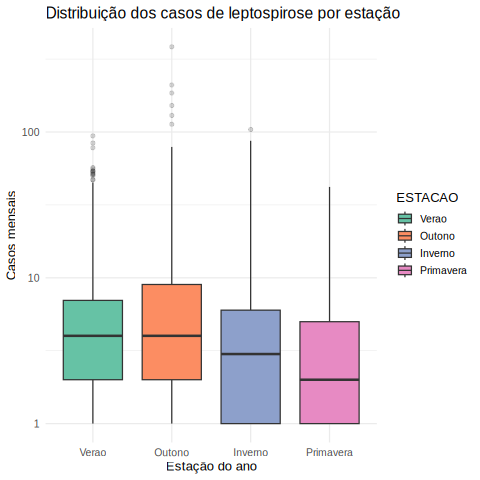

In [ ]:
%%R

ggplot(dados_MBA, aes(x = ESTACAO, y = CASOS, fill = ESTACAO)) +
  geom_boxplot(outlier.alpha = 0.2) +
  scale_fill_brewer(palette = "Set2") +
  scale_y_log10() +
  labs(title = "Distribuição dos casos de leptospirose por estação",
       x = "Estação do ano", y = "Casos mensais") +
  theme_minimal(base_size = 13)


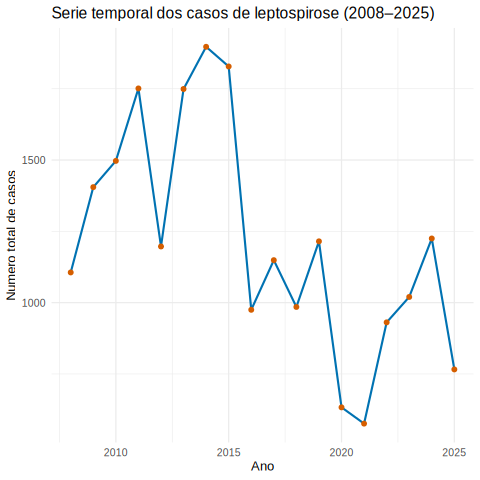

In [ ]:
%%R

casos_ano <- dados_MBA %>%
  group_by(ANO) %>%
  summarise(casos_totais = sum(CASOS, na.rm = TRUE))

ggplot(casos_ano, aes(x = ANO, y = casos_totais)) +
  geom_line(color = "#0072B2", linewidth = 1) +
  geom_point(color = "#D55E00", size = 2) +
  labs(title = "Serie temporal dos casos de leptospirose (2008–2025)",
       x = "Ano", y = "Numero total de casos") +
  theme_minimal(base_size = 13)

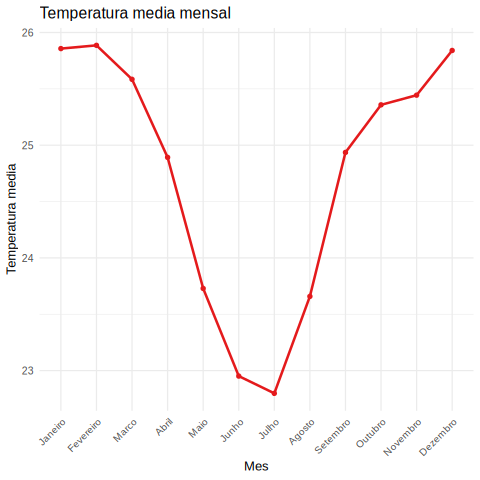

In [ ]:
%%R

ggplot(clima_mensal, aes(x = MES, y = TEMPERATURA, group = 1)) +
  geom_line(color = "#E41A1C", linewidth = 1.2) +
  geom_point(color = "#E41A1C") +
  labs(title = "Temperatura media mensal",
       x = "Mes", y = "Temperatura media") +
  theme_minimal(base_size = 13) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

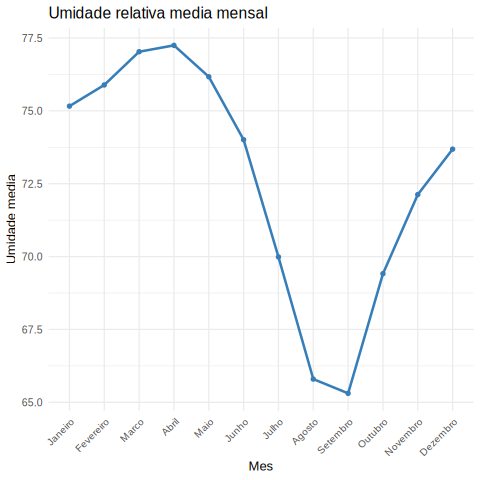

In [ ]:
%%R

ggplot(clima_mensal, aes(x = MES, y = UMIDADE, group = 1)) +
  geom_line(color = "#377EB8", linewidth = 1.2) +
  geom_point(color = "#377EB8") +
  labs(title = "Umidade relativa media mensal",
       x = "Mes", y = "Umidade media") +
  theme_minimal(base_size = 13) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

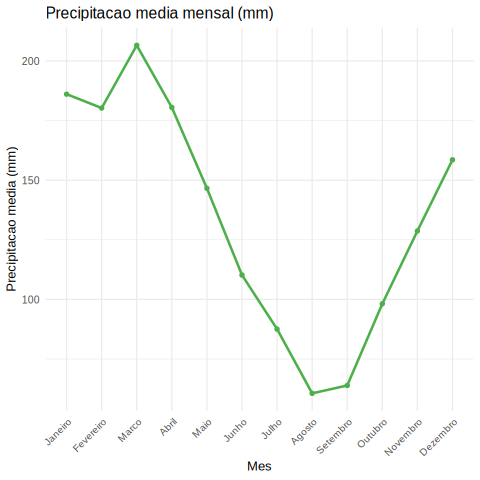

In [ ]:
%%R

ggplot(clima_mensal, aes(x = MES, y = PRECIPITACAO, group = 1)) +
  geom_line(color = "#4DAF4A", linewidth = 1.2) +
  geom_point(color = "#4DAF4A") +
  labs(title = "Precipitacao media mensal (mm)",
       x = "Mes", y = "Precipitacao media (mm)") +
  theme_minimal(base_size = 13) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


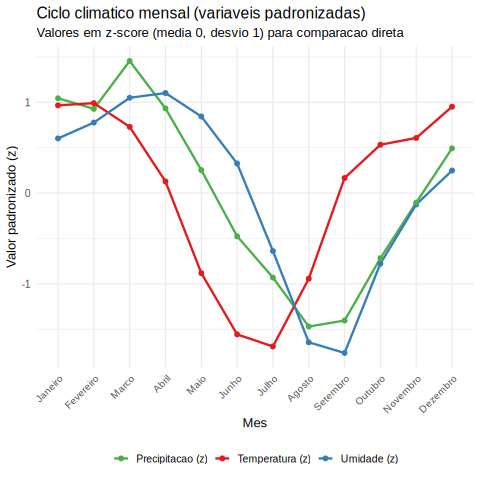

In [ ]:
%%R

clima_long <- clima_mensal %>%
  pivot_longer(cols = c(TEMPERATURA, UMIDADE, PRECIPITACAO),
               names_to = "variavel", values_to = "valor") %>%
  group_by(variavel) %>%
  mutate(valor_z = as.numeric(scale(valor))) %>%
  ungroup()

cores <- c(TEMPERATURA="#E41A1C", UMIDADE="#377EB8", PRECIPITACAO="#4DAF4A")

ggplot(clima_long, aes(x = MES, y = valor_z, group = variavel, color = variavel)) +
  geom_line(linewidth = 1.1) +
  geom_point(size = 2) +
  scale_color_manual(values = cores,
                     labels = c("Precipitacao (z)","Temperatura (z)","Umidade (z)"),
                     name = NULL) +
  labs(title = "Ciclo climatico mensal (variaveis padronizadas)",
       subtitle = "Valores em z-score (media 0, desvio 1) para comparacao direta",
       x = "Mes", y = "Valor padronizado (z)") +
  theme_minimal(base_size = 13) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "bottom")


## *ANÁLISES DAS SÉRIES TEMPORAIS*

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by ANO and MES.
ℹ Output is grouped by ANO.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(ANO, MES))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


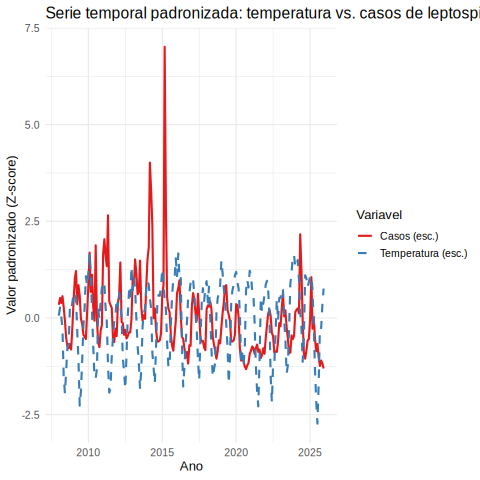

In [ ]:
%%R

dados_ts <- dados_MBA %>%
  group_by(ANO, MES) %>%
  summarise(temp = mean(TEMPERATURA, na.rm = TRUE),
            casos = sum(CASOS, na.rm = TRUE)) %>%
  ungroup() %>%
  mutate(data = as.Date(paste(ANO, match(MES, levels(dados_MBA$MES)), "01", sep = "-")),
         casos_esc = scale(casos),
         temp_esc  = scale(temp))

ggplot(dados_ts, aes(x = data)) +
  geom_line(aes(y = casos_esc, color = "Casos (esc.)"), linewidth = 1) +
  geom_line(aes(y = temp_esc, color = "Temperatura (esc.)"), linewidth = 1, linetype = "dashed") +
  scale_color_manual(values = c("#E41A1C","#377EB8")) +
  labs(title = "Serie temporal padronizada: temperatura vs. casos de leptospirose",
       x = "Ano", y = "Valor padronizado (Z-score)",
       color = "Variavel") +
  theme_minimal(base_size = 13)


`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by ANO and MES.
ℹ Output is grouped by ANO.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(ANO, MES))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


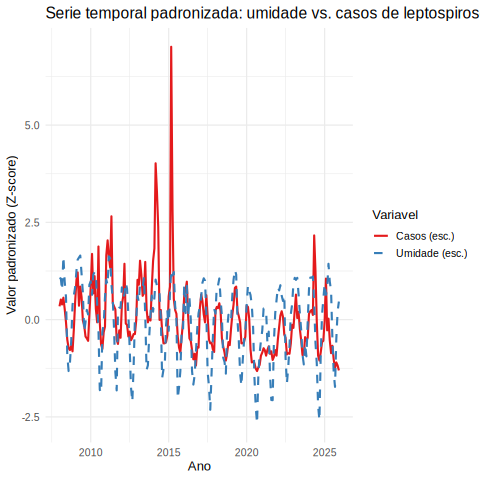

In [ ]:
%%R

dados_ts <- dados_MBA %>%
  group_by(ANO, MES) %>%
  summarise(temp = mean(UMIDADE, na.rm = TRUE),
            casos = sum(CASOS, na.rm = TRUE)) %>%
  ungroup() %>%
  mutate(data = as.Date(paste(ANO, match(MES, levels(dados_MBA$MES)), "01", sep = "-")),
         casos_esc = scale(casos),
         temp_esc  = scale(temp))


ggplot(dados_ts, aes(x = data)) +
  geom_line(aes(y = casos_esc, color = "Casos (esc.)"), linewidth = 1) +
  geom_line(aes(y = temp_esc, color = "Umidade (esc.)"), linewidth = 1, linetype = "dashed") +
  scale_color_manual(values = c("#E41A1C","#377EB8")) +
  labs(title = "Serie temporal padronizada: umidade vs. casos de leptospirose",
       x = "Ano", y = "Valor padronizado (Z-score)",
       color = "Variavel") +
  theme_minimal(base_size = 13)


`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by ANO and MES.
ℹ Output is grouped by ANO.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(ANO, MES))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


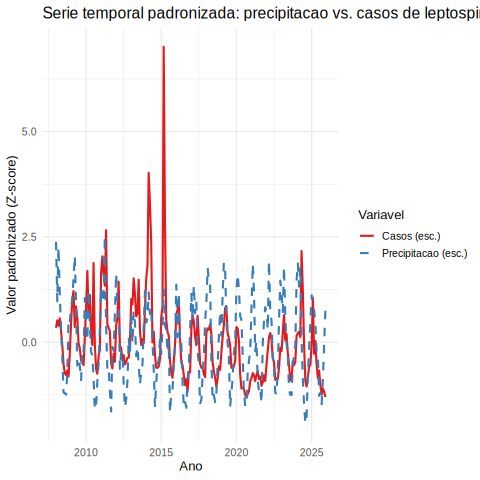

In [ ]:
%%R

dados_ts <- dados_MBA %>%
  group_by(ANO, MES) %>%
  summarise(temp = mean(PRECIPITACAO, na.rm = TRUE),
            casos = sum(CASOS, na.rm = TRUE)) %>%
  ungroup() %>%
  mutate(data = as.Date(paste(ANO, match(MES, levels(dados_MBA$MES)), "01", sep = "-")),
         casos_esc = scale(casos),
         temp_esc  = scale(temp))

ggplot(dados_ts, aes(x = data)) +
  geom_line(aes(y = casos_esc, color = "Casos (esc.)"), linewidth = 1) +
  geom_line(aes(y = temp_esc, color = "Precipitacao (esc.)"), linewidth = 1, linetype = "dashed") +
  scale_color_manual(values = c("#E41A1C","#377EB8")) +
  labs(title = "Serie temporal padronizada: precipitacao vs. casos de leptospirose",
       x = "Ano", y = "Valor padronizado (Z-score)",
       color = "Variavel") +
  theme_minimal(base_size = 13)


In [ ]:
%%R

plot_loess <- function(df, var, label){
  rho <- suppressWarnings(cor(df$CASOS, df[[var]], method = "spearman", use = "complete.obs"))
  ggplot(df, aes(x = .data[[var]], y = CASOS, color = ESTACAO)) +
    geom_point(alpha = 0.3, size = 1.2) +
    geom_smooth(method = "loess", se = FALSE, linewidth = 1) +
    scale_y_continuous(labels = label_number(big.mark = ".", decimal.mark = ",")) +
    labs(
      x = label, y = "Casos de leptospirose",
      title = paste0("Casos vs. ", label, " (LOESS)"),
      subtitle = paste0("Spearman ρ = ", round(rho, 3))
    ) +
    theme_minimal(base_size = 12) +
    theme(legend.position = "bottom")
}


`geom_smooth()` using formula = 'y ~ x'



(`stat_smooth()`). 

(`geom_point()`). 



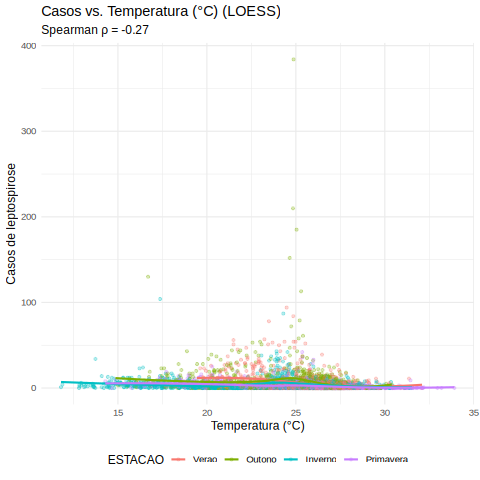

In [ ]:
%%R

g_temp  <- plot_loess(dados_MBA, "TEMPERATURA",  "Temperatura (°C)")

g_temp

`geom_smooth()` using formula = 'y ~ x'



(`stat_smooth()`). 

(`geom_point()`). 



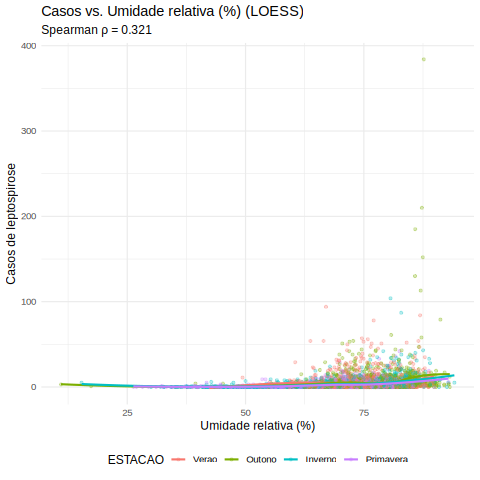

In [ ]:
%%R

g_umid  <- plot_loess(dados_MBA, "UMIDADE", "Umidade relativa (%)")

g_umid


`geom_smooth()` using formula = 'y ~ x'


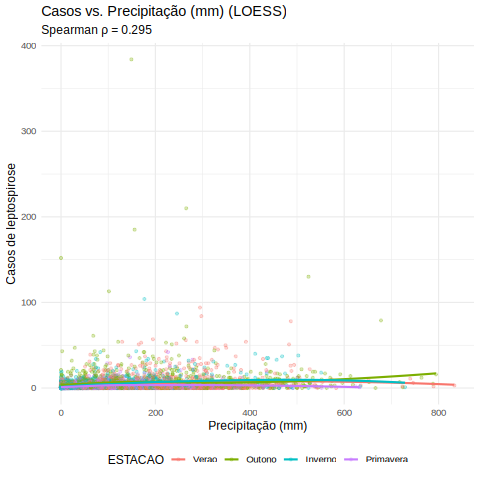

In [ ]:
%%R

g_chuva <- plot_loess(dados_MBA, "PRECIPITACAO", "Precipitação (mm)")

g_chuva


In [ ]:
%%R

kw_casos <- kruskal.test(dados_MBA, CASOS ~ ESTACAO)

kw_casos



	Kruskal-Wallis rank sum test

data:  dados_MBA
Kruskal-Wallis chi-squared = 32686, df = 7, p-value < 2.2e-16



In addition: Warning messages:
1: In kruskal.test.default(dados_MBA, CASOS ~ ESTACAO) :
  'x' is a list, so ignoring argument 'g'
2: In kruskal.test.default(dados_MBA, CASOS ~ ESTACAO) :
  some elements of 'x' are not numeric and will be coerced to numeric


In [ ]:
%%R

dunn_casos <- dunnTest(CASOS ~ ESTACAO, data = dados_MBA, method = "bonferroni")

print(dunn_casos)


           Comparison         Z      P.unadj        P.adj
1      Verao - Outono -4.301612 1.695600e-05 1.017360e-04
2     Verao - Inverno  2.354035 1.857088e-02 1.114253e-01
3    Outono - Inverno  6.645373 3.024496e-11 1.814698e-10
4   Verao - Primavera  7.162454 7.924575e-13 4.754745e-12
5  Outono - Primavera 11.457861 2.147529e-30 1.288517e-29
6 Inverno - Primavera  4.794710 1.629106e-06 9.774636e-06


  Kruskal-Wallis rank sum test

data: x and g
Kruskal-Wallis chi-squared = 136.9521, df = 3, p-value = 0


                      Dunn's Pairwise Comparison of x by g                      
                                  (Bonferroni)                                  

Col Mean-│
Row Mean │      Verao     Outono    Inverno
─────────┼─────────────────────────────────
  Outono │  -4.301611
         │     0.0001*
         │
 Inverno │   2.354034   6.645373
         │     0.1114     0.0000*
         │
Primaver │   7.162453   11.45786   4.794709
         │     0.0000*    0.0000*    0.0000*

FWER = 0.05
Reject Ho if adjusted p ≤ FWER, where (unadjusted) p = Pr(|Z| ≥ |z|)
Dunn (1964) Kruskal-Wallis multiple comparison
  p-values adjusted with the Bonferroni method.



In [ ]:
%%R

serie_mensal <- dados_sem_na %>%
  group_by(ANO, MES) %>%
  summarise(
    CASOS = sum(CASOS, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(ANO, MES)

serie_ts <- ts(
  serie_mensal$CASOS,
  start = c(min(serie_mensal$ANO), 1),
  frequency = 12
)

serie_ts

     Jan Feb Mar Apr May Jun Jul Aug Sep Oct Nov Dec
2008 123 134 126 137 119  97  69  55  52  59  50  85
2009 130 166 178 124 155 138 100  92  74  71  67 110
2010 154 208 144 172 119  97 220  97  61  52  81  90
2011 206 229 204 186 269 128 123 118  69  62  84  66
2012 118 117 120  71  85  74  82  68  72  78  78 100
2013 165 157 197 172 140 144 195 119  97 106 100 153
2014 197 217 355 309 252 101 117  82  63  63  65  76
2015 139 155 544 279 135 117 111  74  56  48  73  97
2016 142 150 163 107  71  67  52  37  46  27  57  56
2017 121 142 132 110  97 141 108  69  63  64  53  49
2018 116 122 120 128 115  71  58  48  35  47  65  60
2019  87 110 126 153 155 115 107  97  61  63  65  74
2020 124 122 103  53  32  33  31  22  18  24  28  43
2021  48  55  52  43  52  57  40  47  31  40  43  33
2022  60  77  95  97  92  54  44  39  47  45  63  93
2023  88 117 142 103 114  86  68  44  45  73  67  72
2024 111 115 117 109 238 179  98  43  35  46  65  66
2025  99 168  82 102  67  45  59  37  23  32  

In [ ]:
%%R

serie_clima <- dados_sem_na %>%
  group_by(ANO, MES) %>%
  summarise(
    CASOS = sum(CASOS, na.rm = TRUE),
    TEMPERATURA = mean(TEMPERATURA, na.rm = TRUE),
    UMIDADE = mean(UMIDADE, na.rm = TRUE),
    PRECIPITACAO = mean(PRECIPITACAO, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(ANO, MES)

serie_clima

# A tibble: 216 × 6
     ANO MES       CASOS TEMPERATURA UMIDADE PRECIPITACAO
   <int> <fct>     <int>       <dbl>   <dbl>        <dbl>
 1  2008 Janeiro     123        24.8    77.5        263. 
 2  2008 Fevereiro   134        25.1    77.4        186. 
 3  2008 Marco       126        24.8    76.0        256. 
 4  2008 Abril       137        24.4    79.9        197. 
 5  2008 Maio        119        22.9    77.1        154. 
 6  2008 Junho        97        22.3    75.2        115. 
 7  2008 Julho        69        23.0    68.5         69.1
 8  2008 Agosto       55        23.8    66.7         68.2
 9  2008 Setembro     52        23.9    67.6         66.4
10  2008 Outubro      59        25.0    70.1         94.1
# ℹ 206 more rows
# ℹ Use `print(n = ...)` to see more rows


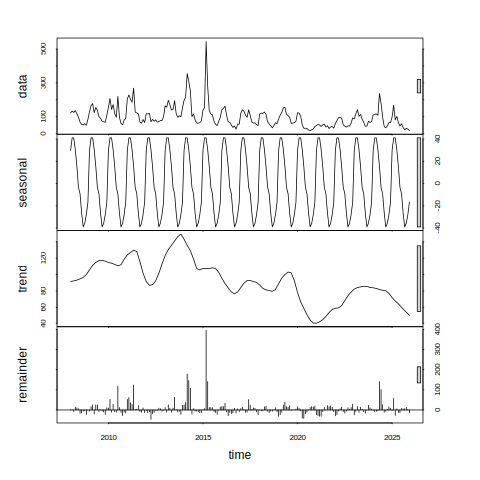

In [ ]:
%%R

decomp <- stl(
  serie_ts,
  s.window = "periodic",
  robust = TRUE
)

plot(decomp)

In [ ]:
%%R

comp <- decomp$time.series

S <- comp[, "seasonal"]
Tend <- comp[, "trend"]
R <- comp[, "remainder"]

forca_sazonal <- max(
  0,
  1 - var(R, na.rm = TRUE) /
    var(S + R, na.rm = TRUE)
)


forca_sazonal


[1] 0.42651


In [ ]:
%%R

forca_tendencia <- max(
  0,
  1 - var(R, na.rm = TRUE) /
    var(Tend + R, na.rm = TRUE)
)

forca_tendencia

[1] 0.3923674


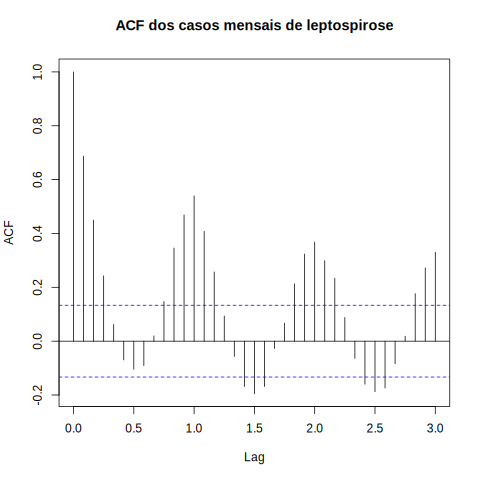

In [ ]:
%%R

acf(
  serie_ts,
  lag.max = 36,
  main = "ACF dos casos mensais de leptospirose"
)

In [ ]:
%%R

adf.test(serie_ts)



	Augmented Dickey-Fuller Test

data:  serie_ts
Dickey-Fuller = -6.2103, Lag order = 5, p-value = 0.01
alternative hypothesis: stationary



In addition: Warning message:
In adf.test(serie_ts) : p-value smaller than printed p-value


In [ ]:
%%R

kpss.test(serie_ts)


	KPSS Test for Level Stationarity

data:  serie_ts
KPSS Level = 1.0516, Truncation lag parameter = 4, p-value = 0.01



In addition: Warning message:
In kpss.test(serie_ts) : p-value smaller than printed p-value


In [ ]:
%%R

corr_global <- list(
  casos_temp  = cor.test(dados_MBA$CASOS, dados_MBA$TEMPERATURA, method = "spearman", exact = FALSE),
  casos_umid  = cor.test(dados_MBA$CASOS, dados_MBA$UMIDADE, method = "spearman", exact = FALSE),
  casos_chuva = cor.test(dados_MBA$CASOS, dados_MBA$PRECIPITACAO, method = "spearman", exact = FALSE)
)

corr_global

$casos_temp

	Spearman's rank correlation rho

data:  dados_MBA$CASOS and dados_MBA$TEMPERATURA
S = 2.7058e+10, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
-0.270389 


$casos_umid

	Spearman's rank correlation rho

data:  dados_MBA$CASOS and dados_MBA$UMIDADE
S = 1.4149e+10, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.3208274 


$casos_chuva

	Spearman's rank correlation rho

data:  dados_MBA$CASOS and dados_MBA$PRECIPITACAO
S = 1.5296e+10, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.2945138 




## *MODELAGEM ESTATÍSTICA*

##### *COMPARAÇÃO ENTRE DISTRIBUIÇÃO DE POISSON E BINOMIAL NEGATIVA*

In [ ]:
%%R

dados_MBA2 <- dados_MBA %>%
  mutate(
    ESTADO = as.factor(ESTADO),
    TEMPERATURA_z = as.numeric(scale(TEMPERATURA)),
    UMIDADE_z = as.numeric(scale(UMIDADE)),
    PRECIPITACAO_z = as.numeric(scale(PRECIPITACAO)),
    ANO_c = ANO - mean(ANO, na.rm = TRUE)
  )

m_pois <- glmer(
  CASOS ~ TEMPERATURA_z + UMIDADE_z + PRECIPITACAO_z + ANO_c +
    (1 | ESTADO),
  data = dados_MBA2,
  family = poisson(link = "log")
)

summary(m_pois)


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: poisson  ( log )
Formula: CASOS ~ TEMPERATURA_z + UMIDADE_z + PRECIPITACAO_z + ANO_c +  
    (1 | ESTADO)
   Data: dados_MBA2

      AIC       BIC    logLik -2*log(L)  df.resid 
  28695.7   28734.8  -14341.9   28683.7      4982 

Scaled residuals: 
   Min     1Q Median     3Q    Max 
-6.449 -0.991 -0.431  0.582 71.677 

Random effects:
 Groups Name        Variance Std.Dev.
 ESTADO (Intercept) 1.635    1.279   
Number of obs: 4988, groups:  ESTADO, 25

Fixed effects:
                Estimate Std. Error z value Pr(>|z|)    
(Intercept)     0.666799   0.256232   2.602  0.00926 ** 
TEMPERATURA_z   0.299869   0.012327  24.325  < 2e-16 ***
UMIDADE_z       0.609913   0.015620  39.046  < 2e-16 ***
PRECIPITACAO_z  0.155156   0.007860  19.739  < 2e-16 ***
ANO_c          -0.027495   0.001332 -20.643  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of F

In addition: Warning message:
In checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv,  :
  Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?


In [ ]:
%%R

disp <- sum(residuals(m_pois, type = "pearson")^2) / df.residual(m_pois)
disp


[1] 5.934713


In [ ]:
%%R

m_nb <- glmmTMB(
  CASOS ~ TEMPERATURA_z + UMIDADE_z + PRECIPITACAO_z + ANO_c +
    (1 | ESTADO),
  data = dados_MBA2,
  family = nbinom2(link = "log")
)

summary(m_nb)


 Family: nbinom2  ( log )
Formula:          CASOS ~ TEMPERATURA_z + UMIDADE_z + PRECIPITACAO_z + ANO_c +  
    (1 | ESTADO)
Data: dados_MBA2

      AIC       BIC    logLik -2*log(L)  df.resid 
  20435.2   20480.8  -10210.6   20421.2      4981 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 ESTADO (Intercept) 1.547    1.244   
Number of obs: 4988, groups:  ESTADO, 25

Dispersion parameter for nbinom2 family (): 1.92 

Conditional model:
                Estimate Std. Error z value Pr(>|z|)    
(Intercept)     0.715173   0.249472   2.867  0.00415 ** 
TEMPERATURA_z   0.237866   0.025358   9.380  < 2e-16 ***
UMIDADE_z       0.461090   0.027246  16.923  < 2e-16 ***
PRECIPITACAO_z  0.182950   0.016978  10.776  < 2e-16 ***
ANO_c          -0.024148   0.002852  -8.467  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


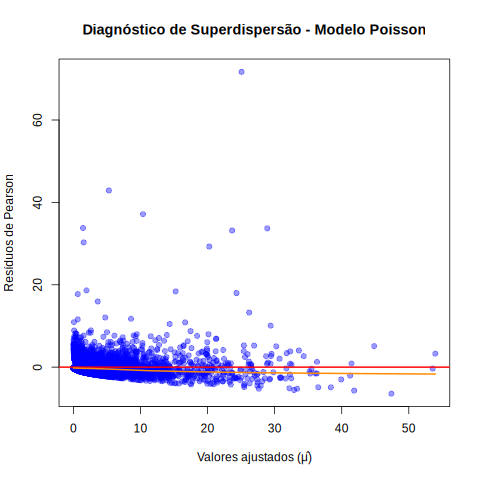

In [ ]:
%%R

diag_df <- data.frame(
  Ajustado = fitted(m_pois),
  Residuos = residuals(m_pois, type = "pearson")
)


plot(diag_df$Ajustado, diag_df$Residuos,
     xlab = "Valores ajustados (μ̂)",
     ylab = "Resíduos de Pearson",
     main = "Diagnóstico de Superdispersão - Modelo Poisson",
     pch = 19, col = rgb(0, 0, 1, 0.4))
abline(h = 0, lwd = 2, col = "red")


lines(lowess(diag_df$Ajustado, diag_df$Residuos), col = "darkorange", lwd = 2)


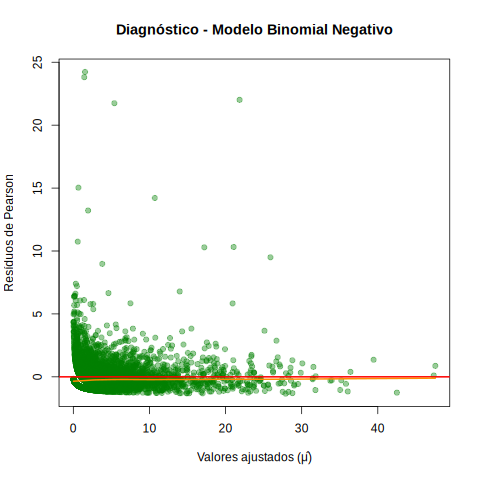

In [ ]:
%%R

diag_nb <- data.frame(Ajustado = fitted(m_nb),
                      Residuos = residuals(m_nb, type = "pearson"))

plot(diag_nb$Ajustado, diag_nb$Residuos,
     xlab = "Valores ajustados (μ̂)",
     ylab = "Resíduos de Pearson",
     main = "Diagnóstico - Modelo Binomial Negativo",
     pch = 19, col = rgb(0, 0.5, 0, 0.4))
abline(h = 0, col = "red", lwd = 2)
lines(lowess(diag_nb$Ajustado, diag_nb$Residuos), col = "darkorange", lwd = 2)


In [ ]:
%%R

dispersion <- function(mod) {
  sum(residuals(mod, type = "pearson")^2) / df.residual(mod)
}

disp_pois <- dispersion(m_pois)
disp_nb   <- dispersion(m_nb)

comparacao <- tibble::tibble(
  Modelo      = c("Poisson", "NegBin"),
  AIC         = c(AIC(m_pois), AIC(m_nb)),
  Dispersao   = c(disp_pois, disp_nb)
)

print(comparacao)

# A tibble: 2 × 3
  Modelo     AIC Dispersao
  <chr>    <dbl>     <dbl>
1 Poisson 28696.      5.93
2 NegBin  20435.      1.66


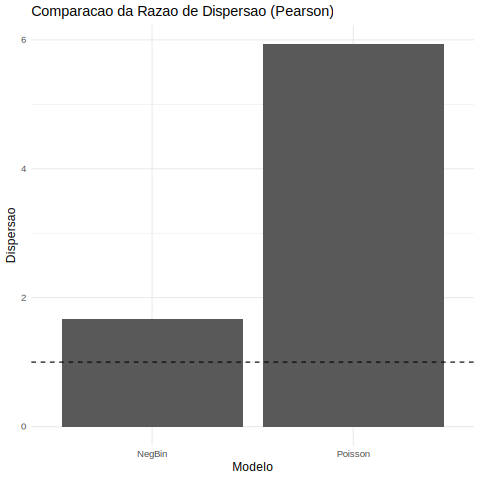

In [ ]:
%%R

g_disp <- ggplot(comparacao, aes(x = Modelo, y = Dispersao)) +
  geom_col() +
  ggtitle("Comparacao da Razao de Dispersao (Pearson)") +
  geom_hline(yintercept = 1, linetype = 2) +
  theme_minimal(base_size = 12)

print(g_disp)


##### *MODELO BINOMIAL NEGATIVO LINEAR*

In [ ]:
%%R

dados_sem_na <- dados_sem_na %>%
  mutate(
    MES_NUM = as.numeric(MES)
  )


In [ ]:
%%R

dados_sem_na <- dados_sem_na %>%
  mutate(
    TEMPO = (ANO - min(ANO)) * 12 + MES_NUM
  )


In [ ]:
%%R

dados_sem_na <- dados_sem_na %>%
  mutate(
    sin12 = sin(2 * pi * TEMPO / 12),
    cos12 = cos(2 * pi * TEMPO / 12)
  )


In [ ]:
%%R

treino <- dados_sem_na %>%
  filter(ANO <= 2022)

teste <- dados_sem_na %>%
  filter(ANO >= 2023)


In [ ]:
%%R

media_temp <- mean(treino$TEMPERATURA, na.rm = TRUE)
dp_temp    <- sd(treino$TEMPERATURA, na.rm = TRUE)

media_umi <- mean(treino$UMIDADE, na.rm = TRUE)
dp_umi    <- sd(treino$UMIDADE, na.rm = TRUE)

media_prec <- mean(treino$PRECIPITACAO, na.rm = TRUE)
dp_prec    <- sd(treino$PRECIPITACAO, na.rm = TRUE)

treino <- treino %>%
  mutate(
    temp_z = (TEMPERATURA - media_temp) / dp_temp,
    umi_z  = (UMIDADE - media_umi) / dp_umi,
    prec_z = (PRECIPITACAO - media_prec) / dp_prec
  )


In [ ]:
%%R

teste <- teste %>%
  mutate(
    temp_z = (TEMPERATURA - media_temp) / dp_temp,
    umi_z  = (UMIDADE - media_umi) / dp_umi,
    prec_z = (PRECIPITACAO - media_prec) / dp_prec
  )


In [ ]:
%%R

modelo_nb_linear <- glmmTMB(
  CASOS ~
    temp_z +
    umi_z +
    prec_z +
    TEMPO +
    sin12 +
    cos12 +
    (1 | ESTADO),
  family = nbinom2,
  data = treino
)

summary(modelo_nb_linear)


 Family: nbinom2  ( log )
Formula:          
CASOS ~ temp_z + umi_z + prec_z + TEMPO + sin12 + cos12 + (1 |      ESTADO)
Data: treino

      AIC       BIC    logLik -2*log(L)  df.resid 
  16864.1   16921.2   -8423.0   16846.1      4214 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 ESTADO (Intercept) 2.021    1.421   
Number of obs: 4223, groups:  ESTADO, 25

Dispersion parameter for nbinom2 family (): 2.37 

Conditional model:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)  0.939187   0.286183   3.282  0.00103 ** 
temp_z       0.486838   0.036857  13.209  < 2e-16 ***
umi_z        0.449241   0.030542  14.709  < 2e-16 ***
prec_z       0.178657   0.017920   9.970  < 2e-16 ***
TEMPO       -0.002929   0.000301  -9.734  < 2e-16 ***
sin12        0.080199   0.026516   3.025  0.00249 ** 
cos12       -0.364587   0.026571 -13.721  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [ ]:
%%R

performance::r2_nakagawa(
  modelo_nb_linear
)


# R2 for Mixed Models

  Conditional R2: 0.846
     Marginal R2: 0.185


In [ ]:
%%R

teste$pred_nb_linear <- predict(
  modelo_nb_linear,
  newdata = teste,
  type = "response"
)


In [ ]:
%%R

MAE <- function(obs, pred) {
  mean(
    abs(obs - pred),
    na.rm = TRUE
  )
}

RMSE <- function(obs, pred) {
  sqrt(
    mean(
      (obs - pred)^2,
      na.rm = TRUE
    )
  )
}


In [ ]:
%%R

mae_linear <- MAE(
  teste$CASOS,
  teste$pred_nb_linear
)

mae_linear


[1] 2.791627


In [ ]:
%%R

rmse_linear <- RMSE(
  teste$CASOS,
  teste$pred_nb_linear
)

rmse_linear


[1] 7.361311


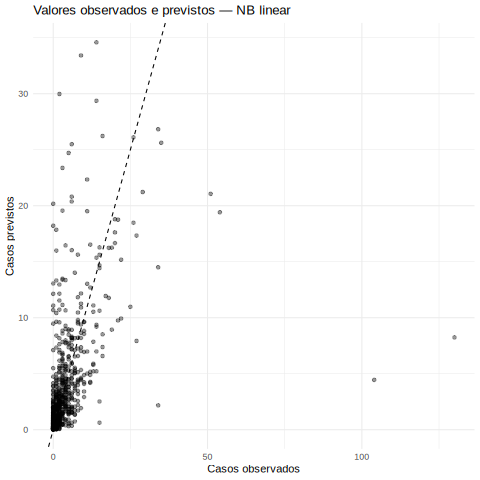

In [ ]:
%%R

ggplot(
  teste,
  aes(
    x = CASOS,
    y = pred_nb_linear
  )
) +
  geom_point(
    alpha = 0.4
  ) +
  geom_abline(
    intercept = 0,
    slope = 1,
    linetype = 2
  ) +
  labs(
    title = "Valores observados e previstos — NB linear",
    x = "Casos observados",
    y = "Casos previstos"
  ) +
  theme_minimal()

##### *MODELO BINOMIAL NEGATIVO QUADRÁTICO*

In [ ]:
%%R

modelo_nb_quadratico <- glmmTMB(
  CASOS ~
    temp_z + I(temp_z^2) +
    umi_z + I(umi_z^2) +
    prec_z + I(prec_z^2) +
    TEMPO +
    sin12 +
    cos12 +
    (1 | ESTADO),
  family = nbinom2,
  data = treino
)

summary(modelo_nb_quadratico)


 Family: nbinom2  ( log )
Formula:          CASOS ~ temp_z + I(temp_z^2) + umi_z + I(umi_z^2) + prec_z +  
    I(prec_z^2) + TEMPO + sin12 + cos12 + (1 | ESTADO)
Data: treino

      AIC       BIC    logLik -2*log(L)  df.resid 
  16761.8   16838.0   -8368.9   16737.8      4211 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 ESTADO (Intercept) 1.872    1.368   
Number of obs: 4223, groups:  ESTADO, 25

Dispersion parameter for nbinom2 family (): 2.53 

Conditional model:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)  1.0137410  0.2764145   3.667 0.000245 ***
temp_z       0.2403762  0.0479545   5.013 5.37e-07 ***
I(temp_z^2) -0.1230161  0.0144969  -8.486  < 2e-16 ***
umi_z        0.4374898  0.0353699  12.369  < 2e-16 ***
I(umi_z^2)   0.0607153  0.0124329   4.883 1.04e-06 ***
prec_z       0.1768013  0.0248056   7.127 1.02e-12 ***
I(prec_z^2) -0.0248354  0.0092479  -2.686 0.007242 ** 
TEMPO       -0.0028238  0.0002965  -9.523  < 2e-16 ***
si

In [ ]:
%%R

performance::r2_nakagawa(
  modelo_nb_quadratico
)


# R2 for Mixed Models

  Conditional R2: 0.838
     Marginal R2: 0.169


In [ ]:
%%R

teste$pred_nb_quadratico <- predict(
  modelo_nb_quadratico,
  newdata = teste,
  type = "response"
)


In [ ]:
%%R

mae_queadratico <- MAE(
  teste$CASOS,
  teste$pred_nb_quadratico
)

mae_queadratico


[1] 2.731156


In [ ]:
%%R

rmse_quadratico <- RMSE(
  teste$CASOS,
  teste$pred_nb_quadratico
)

rmse_quadratico


[1] 7.270968


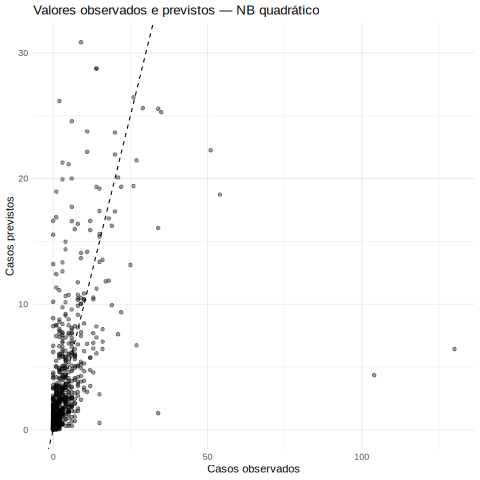

In [ ]:
%%R

ggplot(
  teste,
  aes(
    x = CASOS,
    y = pred_nb_quadratico
  )
) +
  geom_point(alpha = 0.4) +
  geom_abline(
    intercept = 0,
    slope = 1,
    linetype = 2
  ) +
  labs(
    title = "Valores observados e previstos — NB quadrático",
    x = "Casos observados",
    y = "Casos previstos"
  ) +
  theme_minimal()


##### *MODELO BINOMIAL NEGATIVO ADITIVO GENERALIZADO*

In [ ]:
%%R

modelo_gam_clima <- gam(
  CASOS ~
    s(temp_z, k = 5) +
    s(umi_z, k = 5) +
    s(prec_z, k = 5) +
    TEMPO +
    sin12 +
    cos12 +
    s(ESTADO, bs = "re"),
  family = nb(),
  method = "REML",
  data = treino
)

summary(modelo_gam_clima)



Family: Negative Binomial(2.623) 
Link function: log 

Formula:
CASOS ~ s(temp_z, k = 5) + s(umi_z, k = 5) + s(prec_z, k = 5) + 
    TEMPO + sin12 + cos12 + s(ESTADO, bs = "re")

Parametric coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)  0.9192267  0.2773799   3.314  0.00092 ***
TEMPO       -0.0027540  0.0002882  -9.557  < 2e-16 ***
sin12        0.1353053  0.0262568   5.153 2.56e-07 ***
cos12       -0.2993725  0.0262614 -11.400  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
             edf Ref.df  Chi.sq  p-value    
s(temp_z)  3.896  3.993  338.23  < 2e-16 ***
s(umi_z)   3.098  3.619  152.97  < 2e-16 ***
s(prec_z)  2.386  2.932   35.44 1.31e-06 ***
s(ESTADO) 23.868 24.000 4142.58  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

R-sq.(adj) =  0.383   Deviance explained =   68%
-REML = 8367.5  Scale est. = 1         n = 4223



Method: REML   Optimizer: outer newton
full convergence after 9 iterations.
Gradient range [-1.011878e-08,1.617043e-05]
(score 8367.528 & scale 1).
Hessian positive definite, eigenvalue range [0.4524622,547.0676].
Model rank =  41 / 41 

Basis dimension (k) checking results. Low p-value (k-index<1) may
indicate that k is too low, especially if edf is close to k'.

             k'   edf k-index p-value
s(temp_z)  4.00  3.90    0.96    0.98
s(umi_z)   4.00  3.10    0.93    0.40
s(prec_z)  4.00  2.39    0.94    0.65
s(ESTADO) 25.00 23.87      NA      NA


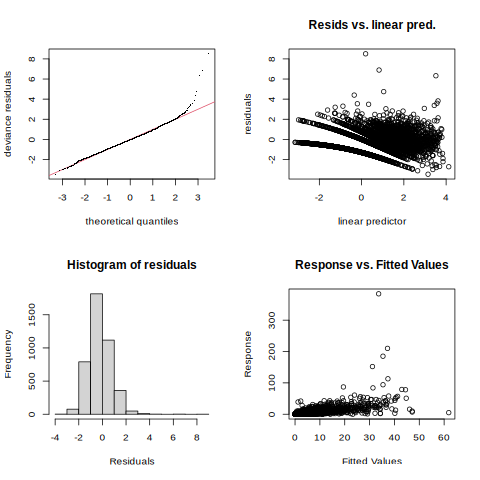

In [ ]:
%%R

gam.check(modelo_gam_clima)


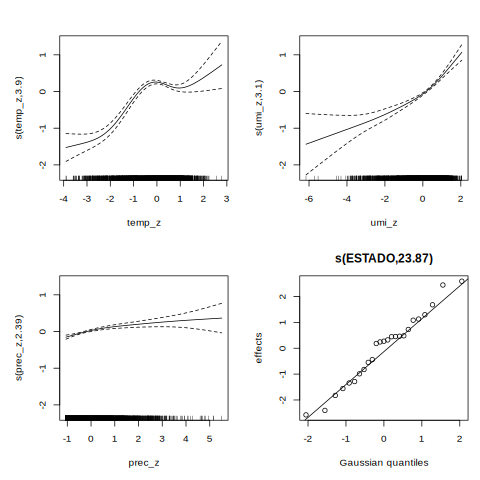

In [ ]:
%%R

plot(
  modelo_gam_clima,
  pages = 1,
  shade = TRUE,
  residuals = FALSE
)


In [ ]:
%%R

teste$pred_gam_nb2 <- predict(
  modelo_gam_clima,
  newdata = teste,
  type = "response"
)


In [ ]:
%%R

MAE(
  teste$CASOS,
  teste$pred_gam_nb2
)


[1] 2.716168


In [ ]:
%%R

RMSE(
  teste$CASOS,
  teste$pred_gam_nb2
)


[1] 7.250251


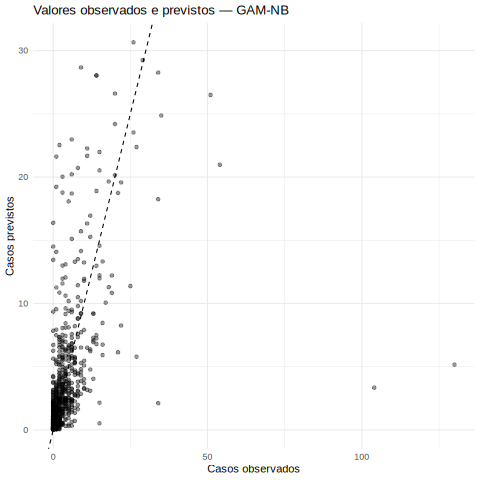

In [ ]:
%%R

ggplot(
  teste,
  aes(
    x = CASOS,
    y = pred_gam_nb2
  )
) +
  geom_point(alpha = 0.4) +
  geom_abline(
    intercept = 0,
    slope = 1,
    linetype = 2
  ) +
  labs(
    title = "Valores observados e previstos — GAM-NB",
    x = "Casos observados",
    y = "Casos previstos"
  ) +
  theme_minimal()


##### *COMPARAÇÃO ENTRE MODELOS*

In [ ]:
%%R

comparacao_pred <- data.frame(
  Modelo = c(
    "NB linear",
    "NB quadrático",
    "GAM-NB"
  ),
  MAE = c(
    MAE(teste$CASOS, teste$pred_nb_linear),
    MAE(teste$CASOS, teste$pred_nb_quadratico),
    MAE(teste$CASOS, teste$pred_gam_nb2)
  ),
  RMSE = c(
    RMSE(teste$CASOS, teste$pred_nb_linear),
    RMSE(teste$CASOS, teste$pred_nb_quadratico),
    RMSE(teste$CASOS, teste$pred_gam_nb2)
  )
)

comparacao_pred

         Modelo      MAE     RMSE
1     NB linear 2.791627 7.361311
2 NB quadrático 2.731156 7.270968
3        GAM-NB 2.716168 7.250251
